<a href="https://colab.research.google.com/github/dyarparvar/NLP-and-Topic-Modelling-of-Customer-Reviews/blob/main/Yarparvar_Darya_CAM_C301_Week_4and5_Topic_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applying NLP for topic modelling in a real-life context

## **Business context**

The **********, as one of the world’s largest value fitness operators, appeals to a broad range of customers by offering high-quality, low-cost, and flexible fitness facilities. The company’s customer-centric proposition – affordable membership fees, no fixed-term contracts, and 24/7 access to high-quality gyms – differentiates it from more traditional gyms and elevates it as a market leader within this space.

This focus on the customer is centred on wanting to understand what motivates members to join and what factors influence their behaviours once they have joined. Understanding how to leverage innovative technology to influence, improve, and simplify their experience allows ********** to foster an open, welcoming, and diverse environment for its members while maintaining the value proposition that ********** is built upon.

With the shift in focus to value-for-money memberships across the gym industry, ********** seeks to achieve its mission of ‘inspiring a healthier world by providing members with affordable access to the benefits being healthy can offer’.


# 📌 Setup
Setting up the notebook environment:
- installing and importing the required libraries
- formatting, styles, and display options for the whole notebook
- discarding warning messages from the output

In [1]:
# --- Mount the drive (datasets are only locally available) ---
from google.colab import drive
# Mount the drive
drive.mount('/content/drive')
# Define the data directory on the Drive
data_dir = '/content/drive/My Drive/Career Accelerator/Course_3/topic_project/data/raw'

Mounted at /content/drive


In [2]:
import os

# Remove any previous folders if present
!rm -rf /content/NLP-and-Topic-Modelling-of-Customer-Reviews

# Change to content directory
os.chdir('/content')

In [3]:
# --- Clone the GitHub repo ---
from getpass import getpass

token = getpass("Enter your GitHub token: ")
!git clone https://{token}@github.com/dyarparvar/NLP-and-Topic-Modelling-of-Customer-Reviews.git

# Navigate to the repo
%cd /content/NLP-and-Topic-Modelling-of-Customer-Reviews
!git status

# Set the parent directory to the repo root directory
parent_dir = os.getcwd()
print(f"\n Parent directory: {parent_dir}")

# Set the directory to save results
results_dir = parent_dir + "/results/"
print(f"\n Result directory: {results_dir}")

# Set the directory to save models
model_dir = results_dir + "/models/"
print(f"\n Model directory: {model_dir}")

Enter your GitHub token: ··········
Cloning into 'NLP-and-Topic-Modelling-of-Customer-Reviews'...
remote: Enumerating objects: 1085, done.
remote: Total 1085 (delta 0), reused 0 (delta 0), pack-reused 1085 (from 3)
Receiving objects: 100% (1085/1085), 163.90 MiB | 25.55 MiB/s, done.
Resolving deltas: 100% (780/780), done.
Updating files: 100% (79/79), done.
/content/NLP-and-Topic-Modelling-of-Customer-Reviews
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean

 Parent directory: /content/NLP-and-Topic-Modelling-of-Customer-Reviews

 Result directory: /content/NLP-and-Topic-Modelling-of-Customer-Reviews/results/

 Model directory: /content/NLP-and-Topic-Modelling-of-Customer-Reviews/results//models/


In [4]:
# --- BeautifulSoup ---
!pip install --quiet beautifulsoup4
from bs4 import BeautifulSoup

In [5]:
# --- NLTK ---
!pip install --quiet nltk
import nltk

# Stopwords for removing common words
nltk.download("stopwords")

# Punkt for tokenization (word_tokenize)
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [6]:
# --- WordCloud ---
from wordcloud import WordCloud

In [7]:
# --- BERTopic ---
!pip install --quiet bertopic
from bertopic import BERTopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [8]:
# --- Pipeline --- "bhadresh-savani/bert-base-uncased-emotion" models (Hugging Face)
from transformers import pipeline

In [9]:
# --- Terminal in Colab ---
!pip install --quiet colab-xterm

%load_ext colabxterm
%xterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 3.9 MB/s eta 0:00:00


Launching Xterm...

<IPython.core.display.Javascript object>

In the terminal:

1. Download **Ollama** ([Ollama](https://ollama.com/download/linux))

    `curl -fsSL https://ollama.com/install.sh | sh`

2. Run the Ollama server at the background without server printing any outputs:

    `ollama serve > /dev/null 2>&1 &`

3. `ollama --help` just to check
4. Fetch the Phi4 model ([Phi4](https://ollama.com/library/phi4))

    `ollama run phi4`


This model is a 14B parameter, open model from Microsoft. Its size is 9.1 GB. The successful loading will be visible as an increase in GPU RAM.

4. `/bye` to exit and get back to terminal.

5. `ollama show phi4` to get some info about Phi4

6. Run Ollama

    `ollama run phi4 --verbose`

6. `fg` to get the server on foreground.

In [10]:
# --- Ollama ---
!pip install --quiet ollama
import ollama
!ollama list

/bin/bash: line 1: ollama: command not found


In [11]:
# --- LDA - Gensim ---
!pip install --quiet gensim
!pip install --quiet pyLDAvis

from gensim import corpora
from gensim.models import LdaModel
from pprint import pprint

import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Enable the interactive visuals in the notebook
pyLDAvis.enable_notebook()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 21.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
# --- Libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from matplotlib_venn import venn3
import plotly.express as px
import datetime

import random
from umap import UMAP
import torch
import warnings


import string
import re

import math

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
# --- Display Options for Pandas ---
# Show all columns and rows in a DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Format floats to consistent decimal places
pd.set_option('display.float_format', lambda x: f'{x:.2f}')



# --- Print Options for NumPy ---
# Suppress the scientific notation and set a consistent number of digits
np.set_printoptions(suppress=True, precision=2)



# --- Styling for Matplotlib and Seaborn ---
# A clean, whitegrid style and a categorical Color Brewer palette
sns.set_theme(style="ticks", palette="Set2")
# sns.despine()

# Font size and styling for the notebook
sns.set_context("notebook", font_scale=0.8)



# --- Warnings ---
# Suppress warnings to keep the output clean
warnings.filterwarnings("ignore")
# Ignore warnings to keep the output clean
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Visualising the chosen palettes & swatches - for further reference

In [14]:
palette_set2 = sns.color_palette("Set2")
palette_set2

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

# 📌 Configuration

A global configuration variable that keeps the parameters that define how the code should run:

In [15]:
CONFIGURATION = {
    "randomness_strategy": {
        "seed": 42
    },

    "missing_value_strategy": {
        "missing_reviews": "remove",
        "missing_locations": "nan" # a class of its own
    },


    "review_preprocessing_strategy": {
        "lower_case": "yes",
        "HTML": "remove",
        "non-ASCII": "remove",
        "punctuation": "remove",
        "digits": "remove",
        "stop_words": "remove",

        "tokenization": "nltk.tokenize.word_tokenize",

    },

    "focus_strategy": {
        "neg_review_threshold": 3,
        "n_worst_locations": 20,
        "n_common_worst_locations": 30,
        "angry_reviews": "anger"

    },


    "frequency_distribution": {
        "noise_words": "minimise",
        "n_most_common" : 10,
        "max_words_wc": 500

    },


     "emotion_analysis": {
        "pipeline": "text-classification",
        "model": "bhadresh-savani/bert-base-uncased-emotion",
        "truncation": True,
        "padding": True,
        "batch_size": 32,
        "device": 0,   # set to zero to always use the T4 GPU in Colab; set to -1 for CPU
        "n_emotions": 1

    },

    "topic_modelling": {
        "bertopic": {
            "calculate_probabilities": True,
            "outlier_handling": "embeddings",
            "verbose": True,
            "language":"multilingual",
            "n_clusters": 10,
            "top_n_topics": 5,
            "n_topics": 200,

        },

        "ollama": {
            "max_review_length": 1000, # max length of input (character) (~250 tokens),

            "model": "phi4",
            "temperature": 0, # deterministic
            "n_ctx": 2048, # short-term memory (industry standard for small tasks)
            "n_predict": 250, # max length of output (token)

            "review_chunk_size": 100,

            "conversation": {
                "system_content": (
                    "You extract topics from customer reviews."
                    "No explanations. No colons. No sentences. No labels. No code blocks."
                    "Output MUST be a numbered list format, with each one on a new line."
                ),
                "user_content": (
                    "In the following customer review, pick out the main 3 topics. "  # change to "pick out up to 3 main topics." to minimise hallucination risk
                    "Return them in a numbered list format, with each one on a new line: "

                ),

                "few_shot_prompt": (
                    "The weights were rusty and the instructor was 20 minutes late."
                ),

                "assistant_content": (
                    "1. Rusty equipment\n2. Instructor lateness\n3. Poor maintenance"
                )
              }


        },

        "gensim": {
            "num_topics": 10,
            "passes": 20,
            "outlier_handling": None # for this model every single document must be assigned to one of the topics by design
        }

    },

    "insights": {
        "model": "phi4",
        "temperature": 0.2, # a bit less deterministic so the model can connect different ideas and yet not hallucinate
        "n_ctx": 4096, # short-term memory (higher to avoid truncated insights)
        "n_predict": 500, # max length of output (token)

        "topic_chunk_size": 1000,

        "conversation": {
            "system_content": (
                "You are an expert data scientist specialising in gym industry consumer insights. "
                "Analyse negative review topics and provide 10 actionable insights tailored to specific stakeholders."
                "\n\nSTAKEHOLDERS & THEIR NEEDS:"
                "\n• Executive Leadership >> Strategic gaps, financial impact"
                "\n• Operations Managers >> Resource allocation, location priorities"
                "\n• Customer Experience >> Service touchpoint failures"
                "\n• Marketing Team >> Brand perception vs. reality"
                "\n• Gym Managers >> Day-to-day operational fixes"
                "\n\nProvide insights that address root causes and specify which stakeholder(s) should act."
                "\n\nFormat (STRICT):"
                "\n1. [Stakeholder]: Theme - Actionable insight."
                "\n2. [Stakeholder]: Theme - Actionable insight."
                "\n3. [Stakeholder]: Theme - Actionable insight."
                "\n4. [Stakeholder]: Theme - Actionable insight."
                "\n5. [Stakeholder]: Theme - Actionable insight."
                "\n...(continue to 10)"
            ),
            "user_content": (
                "For the following text topics obtained from negative customer reviews, "
                "can you give some actionable insights that would help this gym company?"
            ),

            "few_shot_prompt": (
                "['Broken treadmills', 'Dusty weights', 'No staff at 6am']"
            ),

            "assistant_content": (
                "1. Equipment Maintenance: Establish a daily pre-opening inspection log for cardio machines.\n"
                "2. Hygiene Standards: Increase cleaning frequency in the free-weights area during off-peak hours.\n"
                "3. Staffing Coverage: Review morning shift schedules to ensure at least one staff member is present for opening."
            )
        }
    },

    "distil": {
        "model": "phi4",
        "temperature": 0.2, # a bit less deterministic so the model can connect different ideas and yet not hallucinate
        "n_ctx": 4096, # short-term memory (higher to avoid truncated insights)
        "n_predict": 500, # max length of output (token)

        "conversation": {
            "system_content": (
                "You are a senior strategic consultant. You will be provided with "
                "a series of thematic actionable insights from various gym locations. "
                "Your task is to synthesise these into the TOP 10 KEY actionable insights "
                "tailored to specific stakeholders. Consolidate similar points to avoid redundancy. "
                "\n\nSTAKEHOLDERS & THEIR NEEDS:"
                "\n• Executive Leadership >> Strategic gaps, financial impact"
                "\n• Operations Managers >> Resource allocation, location priorities"
                "\n• Customer Experience >> Service touchpoint failures"
                "\n• Marketing Team >> Brand perception vs. reality"
                "\n• Gym Managers >> Day-to-day operational fixes"
                "\n\nProvide insights that address root causes and specify which stakeholder(s) should act."
                "\n\nFormat (STRICT):"
                "\n1. [Stakeholder]: Theme - Actionable insight."
                "\n2. [Stakeholder]: Theme - Actionable insight."
                "\n3. [Stakeholder]: Theme - Actionable insight."
                "\n4. [Stakeholder]: Theme - Actionable insight."
                "\n5. [Stakeholder]: Theme - Actionable insight."
                "\n...(continue to 10)"
            ),
            "user_content": (
                "Below is the consolidated list of intermediate insights from "
                "all topics extracted from negative reviews. Please synthesise "
                "them into the final 10 strategic priorities: "
            ),

            "few_shot_prompt": (
                "1. Facility Issues: Cleanliness is poor and lockers are broken.\n"
                "2. Staff Behavior: Trainers are often late or unresponsive.\n"
                "3. Technical Problems: The app crashes during class bookings."
            ),

            "assistant_content": (
                "1. [Operations/Gym Managers]: Facility Cleanliness - Implement twice-daily deep cleaning schedules with visible completion checklists for changing rooms to address poor cleanliness standards.\n"
                "2. [Operations/Gym Managers]: Equipment Maintenance - Establish weekly locker inspection and repair protocol with replacement target of 48 hours to eliminate broken locker complaints.\n"
                "3. [Gym Managers/Customer Experience]: Staff Responsiveness - Introduce mandatory response time standards (within 24 hours) for trainer communications and implement tracking system to monitor compliance.\n"
                "4. [Gym Managers]: Staff Punctuality - Deploy automated check-in system for trainers with penalties for tardiness to ensure reliable session delivery.\n"
                "5. [Executive/Customer Experience]: App Stability - Conduct urgent technical audit of mobile app class booking functionality and allocate emergency budget for server capacity upgrades to prevent crashes."
            )
        }
    }

}

In [16]:
config = dict(CONFIGURATION)

# 📌 Helper Functions

## Reproducibility

Function to establish reproducibility by fixing the seed

In [17]:
def set_seed(seed=42):
    # Python randomness
    random.seed(seed)
    # Python hash randomness
    os.environ["PYTHONHASHSEED"] = str(seed)

    # NumPy randomness
    np.random.seed(seed)

    # UMAP stability
    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=seed,
        n_jobs=1 # to ensure the GPU/CPU doesn't reorder calculations
    )

    # Torch and T4 GPU
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    return umap_model

In [18]:
SEED = config["randomness_strategy"]["seed"]

In [19]:
umap_model = set_seed(SEED)

## Cleaning and Pre-processing

In [20]:
def clean_location_names(data, location_name_col):
    # Create a copy
    data = data.copy()

    # Convert to lowercase for consistency
    data[location_name_col] = data[location_name_col].str.lower()

    # Remove leading/trailing whitespace and non-breaking spaces
    data[location_name_col] = data[location_name_col].str.strip()
    data[location_name_col] = data[location_name_col].str.replace("\xa0", " ", regex=False)

    # Replace hyphens with single space
    data[location_name_col] = data[location_name_col].str.replace("-", " ", regex=False)

    # Replace multiple spaces with single space
    data[location_name_col] = data[location_name_col].str.replace(r"\s+", " ", regex=True)

    return data

In [21]:
# Function to remove irrelevant characters
def remove_irr_char(data, text_col):
    # Create a copy
    data = data.copy()

    # Remove non-ASCII (emojis, etc.) and replace with space
    data[text_col] = data[text_col].str.replace(r"[^\x00-\x7F]+", " ", regex=True)

    # Remove punctuation and digits
    chars_to_remove = re.escape(string.punctuation + string.digits)
    # Create a regex character class [ ] and remove them
    data[text_col] = data[text_col].str.replace(f"[{chars_to_remove}]", "", regex=True)

    # Collapse multiple spaces, newlines, and tabs into a single space
    data[text_col] = data[text_col].str.replace(r"\s+", " ", regex=True)

    # Trim
    data[text_col] = data[text_col].str.strip()

    return data[text_col]

In [22]:
# Function that cleans and tokenizes each review
def pre_process(data, text_col, processed_col, token_col, filtered_token_col, stop_words):
  # Convert to lowercase to maintain consistency
  data[processed_col] = data[text_col].str.lower()

  # Use BeautifulSoup for HTML cleaning
  data[processed_col] = data[processed_col].apply(
      lambda txt: BeautifulSoup(str(txt), "html.parser").get_text()
  )

  # Remove puncutations, numbers, irrelevant charachters, etc.
  data[processed_col] = remove_irr_char(data, processed_col)

  # Tokenize the into tokens
  data[token_col] = data[processed_col].apply(word_tokenize)

  # Filter stopwords
  data[filtered_token_col] = data[token_col].apply(
      lambda tokens: [token for token in tokens if token not in stop_words]
  )

  return data

## Emotional Analysis

In [23]:
# Function that gets the top emotion for the reviews
def get_top_emotion(data, text_col, classifier):
    data = data.copy()

    # Convert to list
    texts = data[text_col].tolist()

    # Get the top emotion for all reviews
    results = classifier(texts)

    # Extract the top emotion label
    top_emotions = [result[0]["label"] for result in results]

    return pd.Series(top_emotions, index=data.index)

## LLM

In [24]:
# Function that gets the top 3 topics for each revew using Phi4
def get_llm_topics(text, config):

  # Input
  conversation = [
      {
        "role": "system",
        "content": config["conversation"]["system_content"]
      },
      {
        "role": "user",
        "content": (
            f"{config["conversation"]["user_content"]}"
            f"{config["conversation"]["few_shot_prompt"]}"
        )
      },
      {
        "role": "assistant",
        "content": config["conversation"]["assistant_content"]
      },
      {
          "role": "user",
          "content": (
            f"{config["conversation"]["user_content"]}"
            f"{text}"
          )
      }
    ]

  # Output
  response = ollama.chat(
      model=config["model"],
      messages=conversation,
      options={
          "temperature": config["temperature"],
          "num_ctx": config["n_ctx"],
          "num_predict": config["n_predict"]
      }
  )

  # Topics
  llm_topics = response.message.content

  return llm_topics

In [25]:
# Function that produces actionable insights based on the topics using Phi4
def get_llm_insights(topics, config):
  conversation = [
      {
          "role": "system",
          "content": config["conversation"]["system_content"]
      },
      {
          "role": "user",
          "content": (
              f"{config["conversation"]["user_content"]}"
              f"{config["conversation"]["few_shot_prompt"]}"
          )
      },
      {
          "role": "assistant",
          "content": config["conversation"]["assistant_content"]
      },
      {
          "role": "user",
          "content": (
              f"{config["conversation"]["user_content"]}"
              f"{topics}"
          )
      }
  ]

  # Output
  response = ollama.chat(
      model=config["model"],
      messages=conversation,
      options={
          "temperature": config["temperature"],
          "num_ctx": config["n_ctx"],
          "num_predict": config["n_predict"]
      }
  )

  llm_insights = response.message.content

  return llm_insights



# Loading Data

In [27]:
# File URLs
file_url_trustpilot = data_dir + "/Trustpilot_12_months.csv"
file_url_google = data_dir + "/Google_12_months.csv"

In [28]:
# Load the data
raw_data_trustpilot = pd.read_csv(file_url_trustpilot)
raw_data_google = pd.read_csv(file_url_google)

In [29]:
raw_data_trustpilot.head()

,Review ID,Review Created (UTC),Review Consumer User ID,Review Title,Review Content,Review Stars,Source Of Review,Review Language,Domain URL,Webshop Name,Business Unit ID,Tags,Company Reply Date (UTC),Location Name,Location ID
0,663d40378de0a14c26c2f63c,5/9/24 23:29,663d4036d5fa24c223106005,A very good environment,A very good environment,5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,5/10/24 8:12,Solihull Sears Retail Park,7b03ccad-4a9d-4a33-9377-ea5bba442dfc
1,663d3c101ccfcc36fb28eb8c,5/9/24 23:11,5f5e3434d53200fa6ac57238,I love to be part of this gym,I love to be part of this gym. Superb value fo...,5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,5/10/24 8:13,Aylesbury,612d3f7e-18f9-492b-a36f-4a7b86fa5647
2,663d375859621080d08e6198,5/9/24 22:51,57171ba90000ff000a18f905,Extremely busy,"Extremely busy, no fresh air.",1,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaN,Sutton Times Square,0b78c808-f671-482b-8687-83468b7b5bc1
3,663d4fa1f25670a3339ccf6d,5/9/24 22:35,663d4fa0d5fa24251d1068e7,Great vibes,"Great vibes, fantastic gym",5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaN,London Finchley,bc3a9a8c-defe-47b3-8ee6-f73a03b7447e
4,663d3251d8367b7b3c4ace64,5/9/24 22:30,60c20598384d84001a4250de,Everything it needs to be,"Clean, well managed, classes are good.",5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,5/10/24 8:14,Crayford,9ce470b7-57df-4533-af2f-c539422fed14


In [30]:
raw_data_trustpilot.shape

(16673, 15)

In [31]:
raw_data_trustpilot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16673 entries, 0 to 16672
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Review ID                 16673 non-null  object 
 1   Review Created (UTC)      16673 non-null  object 
 2   Review Consumer User ID   16673 non-null  object 
 3   Review Title              16673 non-null  object 
 4   Review Content            16673 non-null  object 
 5   Review Stars              16673 non-null  int64  
 6   Source Of Review          16673 non-null  object 
 7   Review Language           16673 non-null  object 
 8   Domain URL                16673 non-null  object 
 9   Webshop Name              16673 non-null  object 
 10  Business Unit ID          16673 non-null  object 
 11  Tags                      0 non-null      float64
 12  Company Reply Date (UTC)  16164 non-null  object 
 13  Location Name             11323 non-null  object 
 14  Locati

In [32]:
raw_data_trustpilot.columns

Index(['Review ID', 'Review Created (UTC)', 'Review Consumer User ID',
       'Review Title', 'Review Content', 'Review Stars', 'Source Of Review',
       'Review Language', 'Domain URL', 'Webshop Name', 'Business Unit ID',
       'Tags', 'Company Reply Date (UTC)', 'Location Name', 'Location ID'],
      dtype='object')

In [33]:
raw_data_google.head()

,Customer Name,SurveyID for external use (e.g. tech support),Club's Name,Social Media Source,Creation Date,Comment,Overall Score
0,**,ekkt2vyxtkwrrrfyzc5hz6rk,Leeds City Centre North,Google Reviews,5/9/24 23:49,NaN,4
1,**,e9b62vyxtkwrrrfyzc5hz6rk,Cambridge Leisure Park,Google Reviews,5/9/24 22:48,Too many students from two local colleges go h...,1
2,**,e2dkxvyxtkwrrrfyzc5hz6rk,London Holborn,Google Reviews,5/9/24 22:08,"Best range of equipment, cheaper than regular ...",5
3,**,e3tfxvyxtkwrrrfyzc5hz6rk,Cheshunt Brookfield Shopping Park,Google Reviews,5/9/24 21:58,"Good gym when it’s not busy, tend to get too b...",4
4,**,edkrxvyxtkwrrrfyzc5hz6rk,Bristol Union Gate,Google Reviews,5/9/24 21:48,"(current member)\n\nGym is quite dirty, more o...",1


In [34]:
raw_data_google.shape

(23250, 7)

In [35]:
raw_data_google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23250 entries, 0 to 23249
Data columns (total 7 columns):
 #   Column                                         Non-Null Count  Dtype 
---  ------                                         --------------  ----- 
 0   Customer Name                                  23250 non-null  object
 1   SurveyID for external use (e.g. tech support)  23250 non-null  object
 2   Club's Name                                    23250 non-null  object
 3   Social Media Source                            23250 non-null  object
 4   Creation Date                                  23250 non-null  object
 5   Comment                                        13898 non-null  object
 6   Overall Score                                  23250 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 1.2+ MB


In [36]:
raw_data_google.columns

Index(['Customer Name', 'SurveyID for external use (e.g. tech support)',
       'Club's Name', 'Social Media Source', 'Creation Date', 'Comment',
       'Overall Score'],
      dtype='object')

# Cleaning Data

Creating cohesive feature names

In [37]:
data_tp = raw_data_trustpilot.rename(columns={
    "Review ID": "review_id",
    "Review Created (UTC)": "review_date",
    "Review Consumer User ID": "user_id",
    "Review Title": "review_title",
    "Review Content": "review_content",
    "Review Stars": "review_stars",
    "Source Of Review": "review_source",
    "Review Language": "review_lang",
    "Domain URL": "domain_url",
    "Webshop Name": "webshop_name",
    "Business Unit ID": "unit_id",
    "Tags": "tags",
    "Company Reply Date (UTC)": "reply_date",
    "Location Name": "location_name",
    "Location ID": "location_id"
})

**Trustpilot**

Checking for duplicated entries

In [38]:
data_tp.duplicated().sum()

np.int64(7)

Removing duplicated entries

In [39]:
data_tp = data_tp.drop_duplicates()
data_tp.duplicated().sum()

np.int64(0)

In [40]:
data_tp.nunique()

,0
review_id,16666
review_date,15332
user_id,16008
review_title,14229
review_content,16366
review_stars,5
review_source,3
review_lang,20
domain_url,1
webshop_name,1


Removing irrelevant features: *review_title, review_source, domain_url, webshop_name, unit_id, tags*

In [41]:
data_tp = data_tp.drop(columns=["review_title", "review_source", "domain_url", "webshop_name", "unit_id", "tags"], axis=1)
data_tp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16666 entries, 0 to 16672
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   review_id       16666 non-null  object
 1   review_date     16666 non-null  object
 2   user_id         16666 non-null  object
 3   review_content  16666 non-null  object
 4   review_stars    16666 non-null  int64 
 5   review_lang     16666 non-null  object
 6   reply_date      16157 non-null  object
 7   location_name   11318 non-null  object
 8   location_id     11318 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.3+ MB


Summary of Differences

AFSv2 is related to paid advertising delivered through the Google AdSense platform, specifically on publisher's sites that use Google's search function.

BasicLink is a specific term used by review platforms (like Trustpilot) for reviews generated via a simple, unverified invitation link, distinguishing them from "unprompted" (organic) reviews or more verified methods.

Organic refers to natural, unpaid search results or reviews that appear due to their inherent relevance, quality, and authority, determined by algorithms, not payment or specific invitations.

Removing any rows with missing reviews (if any)

In [42]:
data_tp.isna().sum()

,0
review_id,0
review_date,0
user_id,0
review_content,0
review_stars,0
review_lang,0
reply_date,509
location_name,5348
location_id,5348


In [43]:
# data_tp = data_tp.dropna(subset=["review_content"], axis=0)
# data_tp.info()

In [44]:
(data_tp["location_name"].isna() & data_tp["location_id"].isna()).sum()

np.int64(5348)

Since missing *review_id* and *location_id* values are present for entries at the same time, we cannot find one missing value knowing the other, even if we have the mapping between them. Therefore we remove the *location_id*.

In [45]:
data_tp = data_tp.drop(columns=["location_id"], axis=1)
data_tp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16666 entries, 0 to 16672
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   review_id       16666 non-null  object
 1   review_date     16666 non-null  object
 2   user_id         16666 non-null  object
 3   review_content  16666 non-null  object
 4   review_stars    16666 non-null  int64 
 5   review_lang     16666 non-null  object
 6   reply_date      16157 non-null  object
 7   location_name   11318 non-null  object
dtypes: int64(1), object(7)
memory usage: 1.1+ MB


Retaining the reviews with missing location name as its own separate class: "nan"

In [46]:
# Retain reviews with missing location name
data_tp["location_name"] = data_tp["location_name"].fillna("nan")
data_tp["location_name"].isna().sum()

np.int64(0)

In [47]:
(data_tp["location_name"]=="nan").sum()

np.int64(5348)

**Google**

Creating cohesive feature names

In [48]:
data_g = raw_data_google.rename(columns={
    "Customer Name": "user_name",
    "SurveyID for external use (e.g. tech support)": "review_id",
    "Club's Name": "location_name",
    "Social Media Source": "social_source",
    "Creation Date": "review_date",
    "Comment": "review_content",
    "Overall Score": "review_stars"
})

Checking for duplicated entries & removing them if needed

In [49]:
data_g.duplicated().sum()

np.int64(0)

In [50]:
data_g.nunique()

,0
user_name,1
review_id,23250
location_name,514
social_source,1
review_date,15880
review_content,13506
review_stars,5


Removing irrelevant features: *user_name, social_source*

In [51]:
data_g = data_g.drop(columns=["user_name", "social_source"], axis=1)
data_g.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23250 entries, 0 to 23249
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   review_id       23250 non-null  object
 1   location_name   23250 non-null  object
 2   review_date     23250 non-null  object
 3   review_content  13898 non-null  object
 4   review_stars    23250 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 908.3+ KB


Removing any rows with missing reviews


In [52]:
data_g.isna().sum()

,0
review_id,0
location_name,0
review_date,0
review_content,9352
review_stars,0


In [53]:
data_g = data_g.dropna(subset=["review_content"], axis=0)
data_g.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13898 entries, 1 to 23248
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   review_id       13898 non-null  object
 1   location_name   13898 non-null  object
 2   review_date     13898 non-null  object
 3   review_content  13898 non-null  object
 4   review_stars    13898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 651.5+ KB


Finding the number of unique locations

In [54]:
data_tp["location_name"].nunique()

377

In [55]:
data_tp["location_name"].unique()

array(['Solihull Sears Retail Park', 'Aylesbury', 'Sutton Times Square',
       'London Finchley', 'Crayford', 'Stirling', 'nan', 'Barnstaple',
       'Catford Rushey Green', 'London Aldgate', 'Hemel Hempstead',
       'Leeds City Centre South', 'London Bermondsey', 'West Bromwich',
       'Broadstairs', 'Kirkcaldy', 'Durham Arnison',
       'London Muswell Hill', 'Chester', 'Camberley', 'Derby',
       'London Croydon', 'Edinburgh West', 'Llantrisant',
       'Wolverhampton South', 'Nottingham Beeston',
       'London Swiss Cottage', 'Widnes', 'Manchester First Street',
       'Dunfermline', 'Bristol Harbourside', 'London Wembley',
       'Sunderland', 'Birmingham Snow Hill Plaza', 'Stoke-on-Trent East',
       'Dumfries', '345', 'London Seven Sisters', 'Norwich Aylsham Road',
       'Lisburn Laganbank', 'Caerphilly', 'South Ruislip',
       'East Grinstead', 'Mansfield', 'Hull Anlaby',
       'Colchester Retail Park', 'Cambridge Leisure Park',
       'Brighton Central', 'London Hayes

In [56]:
data_g["location_name"].nunique()

512

In [57]:
data_g["location_name"].unique()

array(['Cambridge Leisure Park', 'London Holborn',
       'Cheshunt Brookfield Shopping Park', 'Bristol Union Gate',
       '209 - Slagelse, Jernbanegade', 'New Barnet',
       '155 - Odense C., Grønløkkevej', 'Glasgow Robroyston',
       'Sunderland', '115 - Dannebrogsgade, Aalborg', 'Hatfield',
       'Sheffield Millhouses', 'Manchester Cheetham Hill',
       'London North Finchley', 'Milton Keynes Kingston Centre',
       'Manchester Exchange Quay', 'Newcastle Eldon Garden', 'Airdrie',
       'Staines', 'Cardiff Central', 'Bangor Wales',
       'Northampton Central', 'West Bromwich', 'Motherwell', 'Stafford',
       'Brugg', 'Lincoln Carlton Centre', 'Colchester Retail Park',
       'London Oval', 'Lyss', 'Glasgow Clydebank',
       'Cambridge Grafton Centre', '114 - Valby, Mosedalvej',
       'Merthyr Tydfil', 'Southampton Central', 'Norwich Castle Mall',
       'Rochdale', 'Aylesbury', 'Liverpool Kirkby', 'Nottingham Beeston',
       'London Enfield', 'Coleraine', '279 - Sct. Jørg

We are dealing with semantic duplicates in location names.

The *location_name* mixes:
- different spellings
- language variants
- neighbourhood vs retail park naming
- centre vs street-level naming
- ID suffixes
- data artefacts ("345", "398", "nan") - We will retain these for now, as they may naturally be eliminated in further steps when narrowing down on locations that have the highest negative reviews.

In [58]:
data_tp = clean_location_names(data_tp, "location_name")
data_g = clean_location_names(data_g, "location_name")

Removing the remaining features that are either irrelevant or out of this project's scope: *review_id, review_date, user_id, reply_date*

In [59]:
data_tp = data_tp.drop(columns=["review_id", "review_date", "user_id", "reply_date"], axis=1)
data_tp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16666 entries, 0 to 16672
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   review_content  16666 non-null  object
 1   review_stars    16666 non-null  int64 
 2   review_lang     16666 non-null  object
 3   location_name   16666 non-null  object
dtypes: int64(1), object(3)
memory usage: 651.0+ KB


In [60]:
data_g = data_g.drop(columns=["review_id", "review_date"], axis=1)
data_g.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13898 entries, 1 to 23248
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   location_name   13898 non-null  object
 1   review_content  13898 non-null  object
 2   review_stars    13898 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 434.3+ KB


# Pre-processing & EDA

In [61]:
set(data_tp["location_name"]) == set(data_g["location_name"])

False

In [62]:
# Get unique locations from each dataset
tp_locations = set(data_tp["location_name"])
g_locations = set(data_g["location_name"])

# Find all locations
all_locations = tp_locations | g_locations

# Find common locations
common_locations = tp_locations & g_locations

# Find locations only in Trustpilot
only_tp = tp_locations - g_locations

# Find locations only in Google
only_g = g_locations - tp_locations

# Print results
print(
    f"\n Total unique locations: {len(all_locations)}"
    f"\n Total Trustpilot locations: {len(tp_locations)}"
    f"\n Total Google locations: {len(g_locations)}"
    f"\n Common locations: {len(common_locations)}"
    f"\n Only in Trustpilot: {len(only_tp)}"
    f"\n Only in Google: {len(only_g)}"
)


 Total unique locations: 570
 Total Trustpilot locations: 377
 Total Google locations: 512
 Common locations: 319
 Only in Trustpilot: 58
 Only in Google: 193


In [63]:
all_locations

{'101 kbh. v., gasværksvej',
 '105 kongensgade, esbjerg',
 '106 frb., c. f. richs vej',
 '107 odense c., slotscenter',
 '108 kbh nv., emdrup station',
 '113 århus n., jbv',
 '114 valby, mosedalvej',
 '115 dannebrogsgade, aalborg',
 '116 allerød, banetorvet',
 '119 gentofte, lyngbyvej',
 '122 husum, frederikssundsvej',
 '123 kbh. ø., århusgade',
 '124 kbh. nv., lygten',
 '126 vesterbro, aalborg',
 '128 århus v., viborgvej',
 '130 sønderborg, centerpassagen',
 '133 korsør, norvangen',
 '134 roskilde, algade',
 '135 nykøbing f., vestensborg allé',
 '136 greve, håndværkerbyen',
 '140 frb., peter bangs vej',
 '142 fredensborg, tinghusvej',
 '144 odder, banegårdsgade',
 '147 ballerup, banegårdspladsen',
 '149 brøndby, nygårds plads',
 '152 århus c., scandinavian',
 '153 viby',
 '155 odense c., grønløkkevej',
 '157 hundige, waves',
 '158 friis, aalborg',
 '161 ringsted, nørregade',
 '163 lyngby, jernbanepladsen',
 '164 frb., forum',
 '165 taastrup, taastrup torv',
 '166 måløv, stationsvej',
 

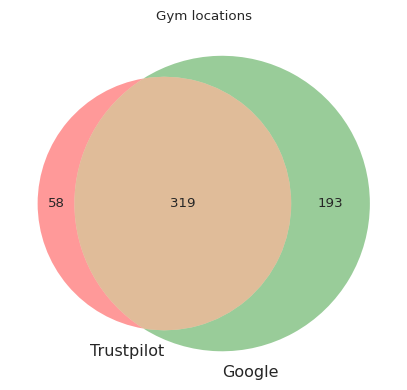

In [64]:
# Plot Venn diagram
plt.figure(figsize=(5, 5))
venn = venn2(
    [tp_locations, g_locations],
    set_labels=("Trustpilot", "Google"),
)

plt.title("Gym locations")
plt.show()

We retain the missing location (nan values) as it is, a separate category of itself.

### 🔹 Insights

- **Time span:** Both Trustpilot and Google data cover a 12-month period.

- **Location coverage:** Trustpilot includes 377 locations and Google includes 512 locations, with 319 locations common to both sources.

- **Trustpilot dataset:** 16673 reviews in total, including 7 duplicates, with 15 features.

- **Google dataset:** 23250 reviews in total, with 9352 missing reviews, and 7 features.


## Pre-processing

In [65]:
processed_data_tp = data_tp.copy()
processed_data_g = data_g.copy()

Removing numbers, charachters, etc. 🟡  what else?

In [66]:
print(f"Punctuations to be removed: {string.punctuation}")

Punctuations to be removed: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


`string.punctuation` only removes the standard ASCII apostrophe ', not the curly ones!

Next step is removing the stop words.
Non-English reviews are retained because Google data does not contain location information. This makes consistent language-based cleaning across sources impossible. Also, retaining non-English reviews may preserve valuable signals.

In [67]:
languages = processed_data_tp["review_lang"].unique()
languages

array(['en', 'it', 'da', 'pl', 'bg', 'ar', 'pt', 'ro', 'es', 'fr', 'sco',
       'sk', 'st', 'de', 'et', 'sv', 'lt', 'ru', 'uk', 'tr'], dtype=object)

In [68]:
processed_data_tp["review_lang"].nunique()

20

In [69]:
processed_data_tp["review_lang"].value_counts(normalize=True)

,proportion
review_lang,
en,0.99
da,0.00
pl,0.00
pt,0.00
es,0.00
it,0.00
ro,0.00
fr,0.00
de,0.00


One approach is to combine the stop words across all available languages:

In [70]:
# Map language codes to NLTK stopwords language names
language_map = {
    'en': 'english',
    'it': 'italian',
    'da': 'danish',
    'pl': None, # not available in NLTK
    'bg': None,  # not available in NLTK
    'ar': 'arabic',
    'pt': 'portuguese',
    'ro': 'romanian',
    'es': 'spanish',
    'fr': 'french',
    'sco': None,  # not available in NLTK
    'sk': None,  # not available in NLTK
    'st': None,  # not available in NLTK
    'de': 'german',
    'et': None,  # not available in NLTK
    'sv': 'swedish',
    'lt': None,  # not available in NLTK
    'ru': 'russian',
    'uk': None,  # not available in NLTK
    'tr': 'turkish'
}

# Collect all stopwords from available languages
all_stopwords = set()
for language_name in language_map.values():
    if language_name:
        all_stopwords.update(stopwords.words(language_name))

Limitation: cross-language collision

- A word treated as "garbage" in one language may be "meaningful" in another.

An additional safety check could be performed. We may quantify pairwise language intersections to assess overlap and potential cross-language collision.

Considering the low proportion of non-English reviews and for initial topic modelling, we assume it is safe enough to combine stop words across all languages without performing further checks.

At the main topic-modelling stage, modern multilingual models should mitigate this issue by handling cross-language semantics and reducing noise during downstream analysis.



In [71]:
# Pre-process the data
processed_data_tp = pre_process(processed_data_tp, "review_content", "review_processed", "tokens", "filtered_tokens", all_stopwords)
processed_data_g = pre_process(processed_data_g, "review_content", "review_processed", "tokens", "filtered_tokens", all_stopwords)

In [72]:
# Re-order the columns
processed_data_tp = processed_data_tp.reindex(
    columns=[
        "filtered_tokens",
        "tokens",
        "review_processed",
        "review_stars",
        "review_content",
        "location_name"
    ]
)
# Re-order the columns
processed_data_g = processed_data_g.reindex(
    columns=[
        "filtered_tokens",
        "tokens",
        "review_processed",
        "review_stars",
        "review_content",
        "location_name"
    ]
)

In [73]:
processed_data_tp.head(3)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name
0,"[good, environment]","[a, very, good, environment]",a very good environment,5,A very good environment,solihull sears retail park
1,"[love, part, gym, superb, value, money, time, ...","[i, love, to, be, part, of, this, gym, superb,...",i love to be part of this gym superb value for...,5,I love to be part of this gym. Superb value fo...,aylesbury
2,"[extremely, busy, fresh, air]","[extremely, busy, no, fresh, air]",extremely busy no fresh air,1,"Extremely busy, no fresh air.",sutton times square


In [74]:
processed_data_g.head(3)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name
1,"[many, students, two, local, colleges, go, lea...","[too, many, students, from, two, local, colleg...",too many students from two local colleges go h...,1,Too many students from two local colleges go h...,cambridge leisure park
2,"[best, range, equipment, cheaper, regular, gym...","[best, range, of, equipment, cheaper, than, re...",best range of equipment cheaper than regular g...,5,"Best range of equipment, cheaper than regular ...",london holborn
3,"[good, gym, busy, tend, get, busy, late, after...","[good, gym, when, it, s, not, busy, tend, to, ...",good gym when it s not busy tend to get too bu...,4,"Good gym when it’s not busy, tend to get too b...",cheshunt brookfield shopping park


## Frequency Distribution

The frequency distribution of the words for each dataset:

In [75]:
freq_dist_config = config["frequency_distribution"]

In [76]:
n_most_common = freq_dist_config["n_most_common"]

In [77]:
# # Using NLTK FreqDist
# fdist_tp = FreqDist(
#     [token for tokens in processed_data_tp["filtered_tokens"] for token in tokens]
#     ).most_common(n_most_common)

# fdist_g = FreqDist(
#     [token for tokens in processed_data_g["filtered_tokens"] for token in tokens]
#     ).most_common(n_most_common)

In [78]:
# pd.Series(dict(fdist_tp))

In [79]:
# pd.Series(dict(fdist_g))

In [80]:
# Using vectorization >> more efficient
fdist_tp = processed_data_tp["filtered_tokens"].explode().value_counts()
fdist_g = processed_data_g["filtered_tokens"].explode().value_counts()

In [81]:
fdist_tp.head(n_most_common)

,count
filtered_tokens,
gym,10823
equipment,4402
good,4080
great,3791
staff,3573
clean,2491
friendly,2488
classes,2259
easy,2188


In [82]:
fdist_g.head(n_most_common)

,count
filtered_tokens,
gym,9890
equipment,3609
great,3557
good,3452
staff,2740
classes,2313
clean,1834
friendly,1730
machines,1705


Irrelevant high-frequency words are removed to reduce noise in the data.

In [83]:
# Filter words that add no extra value to the analysis, like "puregym"
noise_words = set()
noise_words.update({"puregym", "pure", "gym", "always"})

processed_data_tp["filtered_tokens"] = processed_data_tp["filtered_tokens"].apply(
    lambda tokens: [token for token in tokens if token not in noise_words]
)

processed_data_g["filtered_tokens"] = processed_data_g["filtered_tokens"].apply(
    lambda tokens: [token for token in tokens if token not in noise_words]
)

The current approach relies on manually defining a set of noise words.

Limitations:  
  - **Scalability issues**: manually curating noise words for large or evolving datasets is inefficient.  
  - **Subjectivity**: deciding which words are "noise" can be arbitrary, risking the removal of contextually meaningful terms.  
  - **Lack of adaptability**: this method cannot automatically adjust to different languages, sentiments, or variations across datasets.  

- A more robust solution would use statistical or model-driven techniques such as word embeddings or LLM-based filtering to automatically identify and remove uninformative tokens.


In [84]:
# # Using NLTK FreqDist

# all_tokens_tp = [token for tokens in processed_data_tp["filtered_tokens"] for token in tokens]
# all_tokens_g = [token for tokens in processed_data_g["filtered_tokens"] for token in tokens]

# fdist_tp = FreqDist(all_tokens_tp)
# fdist_g = FreqDist(all_tokens_g)

# most_common_tp = pd.DataFrame(fdist_tp.most_common(n_most_common),
#                               columns=["token", "frequency"])
# most_common_g = pd.DataFrame(fdist_g.most_common(n_most_common),
#                              columns=["token", "frequency"])

In [85]:
# Using vectorization >> more efficient
fdist_tp = processed_data_tp["filtered_tokens"].explode().value_counts()
fdist_g = processed_data_g["filtered_tokens"].explode().value_counts()

Visualisation of the most frequently repeated words for each dataset:

In [86]:
most_common_tp = fdist_tp.head(n_most_common)
most_common_g = fdist_g.head(n_most_common)

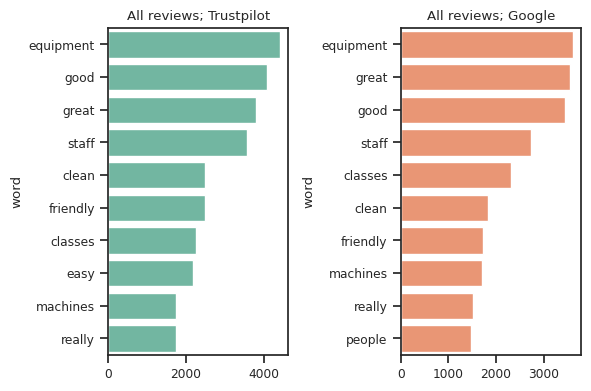

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes = axes.flatten()

# Plot most common words
sns.barplot(y=most_common_tp.index, x=most_common_tp.values, ax=axes[0], color=palette_set2[0])
sns.barplot(y=most_common_g.index, x=most_common_g.values, ax=axes[1], color=palette_set2[1])

axes[0].set_title("All reviews; Trustpilot")
axes[1].set_title("All reviews; Google")
axes[0].set_ylabel("word")
axes[1].set_ylabel("word")

plt.tight_layout()
plt.show()

In [88]:
# Common high-frequency words between two datasets (all reviews)
set(most_common_tp.index) & set(most_common_g.index)

{'classes',
 'clean',
 'equipment',
 'friendly',
 'good',
 'great',
 'machines',
 'really',
 'staff'}

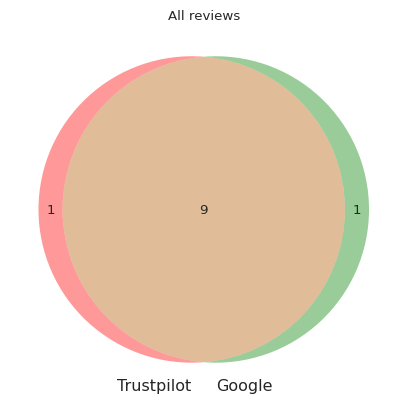

In [89]:
# Plot Venn diagram
plt.figure(figsize=(5, 5))
venn = venn2(
    [set(most_common_tp.index), set(most_common_g.index)],
    set_labels=("Trustpilot", "Google"),
)

plt.title("All reviews")
plt.show()

WordCloud visualisation of the most frequently repeated words for each dataset:

In [90]:
max_words_wc = freq_dist_config["max_words_wc"]

In [91]:
all_tokens_tp = [token for tokens in processed_data_tp["filtered_tokens"] for token in tokens]
all_tokens_g = [token for tokens in processed_data_g["filtered_tokens"] for token in tokens]

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

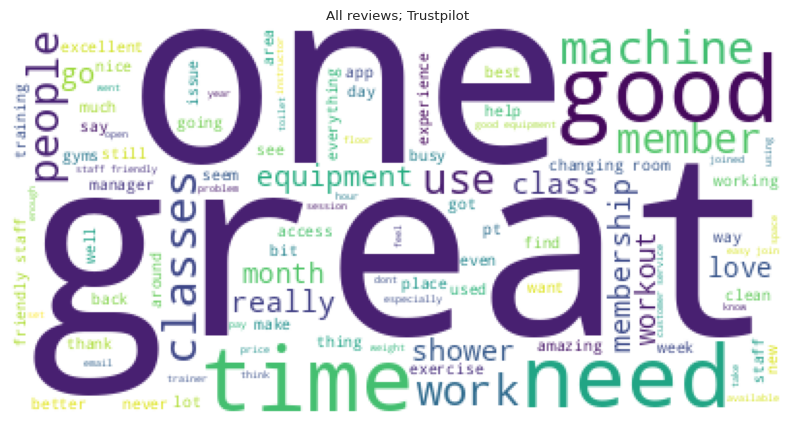

In [92]:
plt.figure(figsize=(10, 8))

word_cloud = WordCloud(
    background_color="white",
    # stopwords=set(),
    max_words=max_words_wc,
    random_state=SEED
)

# WordCloud analyses word frequency across all text, so it needs all words combined
word_cloud.generate(" ".join(all_tokens_tp))
plt.imshow(word_cloud)
plt.title("All reviews; Trustpilot")
plt.axis("off")

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

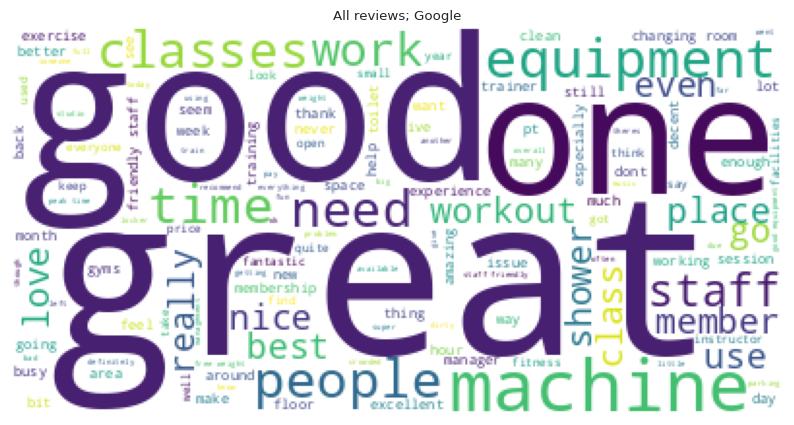

In [93]:
plt.figure(figsize=(10, 8))

word_cloud = WordCloud(
    background_color="white",
    # stopwords=set(),
    max_words=max_words_wc,
    random_state=SEED
)

# WordCloud analyses word frequency across all text, so it needs all words combined
word_cloud.generate(" ".join(all_tokens_g))
plt.imshow(word_cloud)
plt.title("All reviews; Google")
plt.axis("off")

### *focus: negative reviews*

- Negative reviews are defined as those with *review_stars* < 3, indicating dissatisfied or critical feedback.  
- Each dataset is filtered to retain only these negative reviews, isolating the most concerning customer experiences.  
- The negative reviews from both datasets are then merged, creating a unified collection that highlights pain points across shared locations.


In [94]:
neg_review_threshold = config["focus_strategy"]["neg_review_threshold"]

In [95]:
processed_data_neg_tp = processed_data_tp[processed_data_tp["review_stars"] < neg_review_threshold]
processed_data_neg_g = processed_data_g[processed_data_g["review_stars"] < neg_review_threshold]

In [96]:
processed_data_neg_tp.shape

(3541, 6)

In [97]:
processed_data_neg_tp.shape[0]/processed_data_tp.shape[0]

0.2124684987399496

In [98]:
processed_data_neg_g

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name
1,"[many, students, two, local, colleges, go, lea...","[too, many, students, from, two, local, colleg...",too many students from two local colleges go h...,1,Too many students from two local colleges go h...,cambridge leisure park
4,"[current, member, quite, dirty, often, theres,...","[current, member, gym, is, quite, dirty, more,...",current member gym is quite dirty more often t...,1,"(current member)\n\nGym is quite dirty, more o...",bristol union gate
5,"[kom, betalte, pr, vetime, centret, fik, blot,...","[kom, og, betalte, for, en, pr, vetime, i, cen...",kom og betalte for en pr vetime i centret fik ...,1,Kom og betalte for en prøvetime i centret. Fik...,"209 slagelse, jernbanegade"
7,"[way, hot, even, workout, windows, open, ac, b...","[this, gym, is, way, too, hot, to, even, worko...",this gym is way too hot to even workout in the...,2,This gym is way too hot to even workout in. Th...,new barnet
19,"[access, wc, empty, assistance, gain, access, ...","[no, access, for, wc, empty, and, no, assistan...",no access for wc empty and no assistance to ga...,2,No access for wc 😢. Empty and no assistance t...,manchester cheetham hill
29,"[year, finally, leaving, gutted, staff, pts, l...","[after, being, at, this, gym, for, over, a, ye...",after being at this gym for over a year im fin...,2,After being at this gym for over a year I'm fi...,newcastle eldon garden
57,"[huge, equipment, could, easily, fit, double, ...","[the, gym, is, huge, but, where, is, all, the,...",the gym is huge but where is all the equipment...,1,The gym is huge but where is all the equipment...,london oval
65,"[airconditioning, doesnt, work]","[airconditioning, doesnt, work]",airconditioning doesnt work,1,Air-conditioning doesnt work,new barnet
67,"[friend, new, joined, struggling, get, scanner...","[my, friend, is, new, to, the, gym, she, had, ...",my friend is new to the gym she had just joine...,1,"My friend is new to the gym, she had just join...",rochdale
70,"[extremely, disappointed, level, hygiene, ment...","[extremely, disappointed, with, the, level, of...",extremely disappointed with the level of hygie...,1,Extremely disappointed with the level of hygie...,liverpool kirkby


In [99]:
processed_data_neg_g.shape[0]/processed_data_g.shape[0]

0.20038854511440496

In [100]:
# # Using NLTK
# neg_tokens_tp = [token for tokens in processed_data_neg_tp["filtered_tokens"] for token in tokens]
# neg_tokens_g = [token for tokens in processed_data_neg_g["filtered_tokens"] for token in tokens]
# fdist_neg_tp = FreqDist(neg_tokens_tp)
# fdist_neg_g = FreqDist(neg_tokens_g)
# most_common_neg_tp = pd.DataFrame(fdist_neg_tp.most_common(n_most_common),
#                               columns=["token", "frequency"])
# most_common_neg_g = pd.DataFrame(fdist_neg_g.most_common(n_most_common),
#                              columns=["token", "frequency"])

In [101]:
# Using vectorization >> more efficient
fdist_neg_tp = processed_data_neg_tp["filtered_tokens"].explode().value_counts()
fdist_neg_g = processed_data_neg_g["filtered_tokens"].explode().value_counts()

Visualisation of the most frequently repeated words in **negative** reviews for each dataset:

In [102]:
most_common_neg_tp = fdist_neg_tp.head(n_most_common)
most_common_neg_g = fdist_neg_g.head(n_most_common)

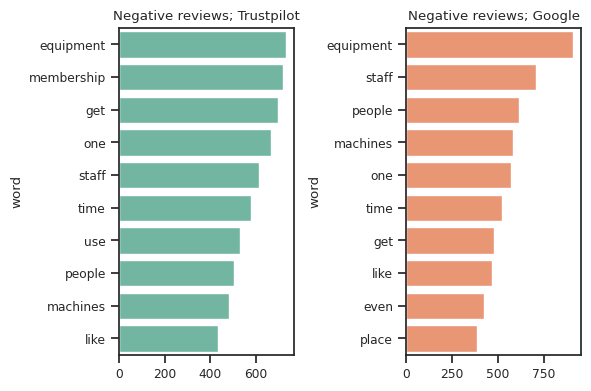

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes = axes.flatten()

# Plot a barplot
sns.barplot(y=most_common_neg_tp.index, x=most_common_neg_tp.values, ax=axes[0], color=palette_set2[0])
sns.barplot(y=most_common_neg_g.index, x=most_common_neg_g.values, ax=axes[1], color=palette_set2[1])

axes[0].set_title("Negative reviews; Trustpilot")
axes[1].set_title("Negative reviews; Google")
axes[0].set_ylabel("word")
axes[1].set_ylabel("word")

plt.tight_layout()
plt.show()

In [104]:
# Common high-frequency words between two datasets (negatiove reviews)
set(most_common_neg_tp.index) & set(most_common_neg_g.index)

{'equipment', 'get', 'like', 'machines', 'one', 'people', 'staff', 'time'}

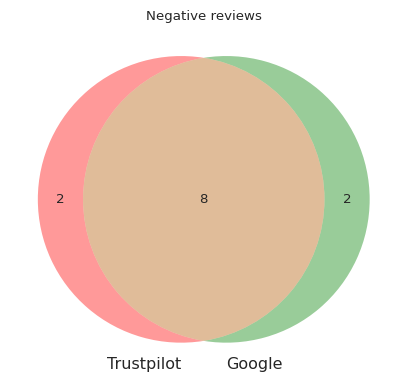

In [105]:
# Plot Venn diagram
plt.figure(figsize=(5, 5))
venn = venn2(
    [set(most_common_neg_tp.index), set(most_common_neg_g.index)],
    set_labels=("Trustpilot", "Google"),
)

plt.title("Negative reviews")
plt.show()

WordCloud visualisation of the most frequently repeated words in **negative** reviews for each dataset:

In [106]:
neg_tokens_tp = [token for tokens in processed_data_neg_tp["filtered_tokens"] for token in tokens]
neg_tokens_g = [token for tokens in processed_data_neg_g["filtered_tokens"] for token in tokens]

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

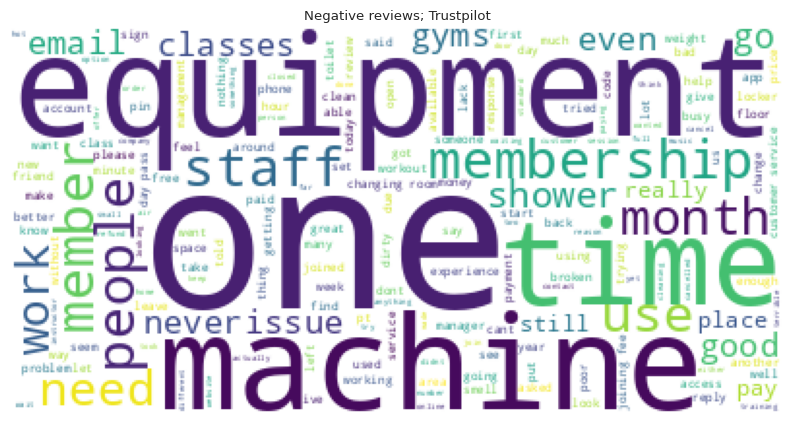

In [107]:
plt.figure(figsize=(10, 8))

word_cloud = WordCloud(
    background_color="white",
    # stopwords=set(),
    max_words=max_words_wc,
    random_state=SEED
)

# WordCloud analyses word frequency across all text, so it needs all words combined
word_cloud.generate(" ".join(neg_tokens_tp))
plt.imshow(word_cloud)
plt.title("Negative reviews; Trustpilot")
plt.axis("off")

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

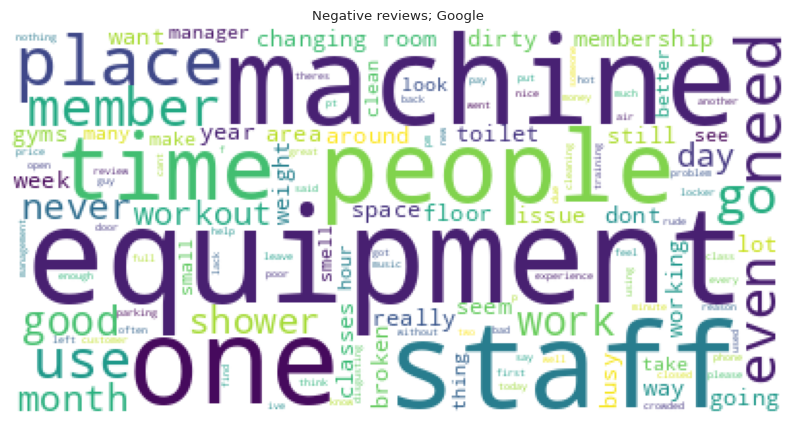

In [108]:
plt.figure(figsize=(10, 8))

word_cloud = WordCloud(
    background_color="white",
    # stopwords=set(),
    max_words=max_words_wc,
    random_state=SEED
)

# WordCloud analyses word frequency across all text, so it needs all words combined
word_cloud.generate(" ".join(neg_tokens_g))
plt.imshow(word_cloud)
plt.title("Negative reviews; Google")
plt.axis("off")

**Combined negative reviews**

In [109]:
processed_data_neg_tp["data_source"] = "trustpilot"
processed_data_neg_g["data_source"] = "google"

In [110]:
processed_data_neg_tp.head(1)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name,data_source
2,"[extremely, busy, fresh, air]","[extremely, busy, no, fresh, air]",extremely busy no fresh air,1,"Extremely busy, no fresh air.",sutton times square,trustpilot


In [111]:
processed_data_neg_g.head(1)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name,data_source
1,"[many, students, two, local, colleges, go, lea...","[too, many, students, from, two, local, colleg...",too many students from two local colleges go h...,1,Too many students from two local colleges go h...,cambridge leisure park,google


In [112]:
processed_data_neg = pd.concat([processed_data_neg_tp, processed_data_neg_g])

just to check eveything is ok!

In [113]:
processed_data_neg.shape[0] - (processed_data_neg_tp.shape[0] + processed_data_neg_g.shape[0])

0

In [114]:
neg_tokens = [token for tokens in processed_data_neg["filtered_tokens"] for token in tokens]

In [115]:
len(" ".join(neg_tokens)) - (len(" ".join(neg_tokens_tp)) + len(" ".join(neg_tokens_g)))

1

(The difference is one single space added between trustpilot and google tokens in the combined list.)

In [116]:
processed_data_neg.shape

(6326, 7)

In [117]:
# Negative reviews (%)
processed_data_neg.shape[0]/(processed_data_tp.shape[0]+processed_data_g.shape[0])

0.20697552676351264

In [118]:
# Using NLTK
# fdist_neg = FreqDist(neg_tokens)
# most_common_neg = pd.DataFrame(fdist_neg.most_common(n_most_common),
#                                columns=["token", "frequency"])

In [119]:
# Using vectorization >> more efficient
fdist_neg = processed_data_neg["filtered_tokens"].explode().value_counts()

Visualisation of the most frequently repeated words in **all negative** reviews:

In [120]:
most_common_neg = fdist_neg.head(n_most_common)

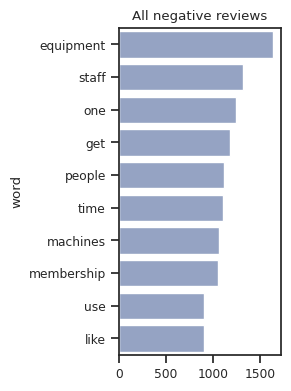

In [121]:
plt.figure(figsize=(3, 4))

# Plot a barplot
sns.barplot(y=most_common_neg.index, x=most_common_neg.values, color=palette_set2[2])

plt.title("All negative reviews")
plt.ylabel("word")

plt.tight_layout()
plt.show()

WordCloud visualisation of the most frequently repeated words in **all negative** reviews:

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

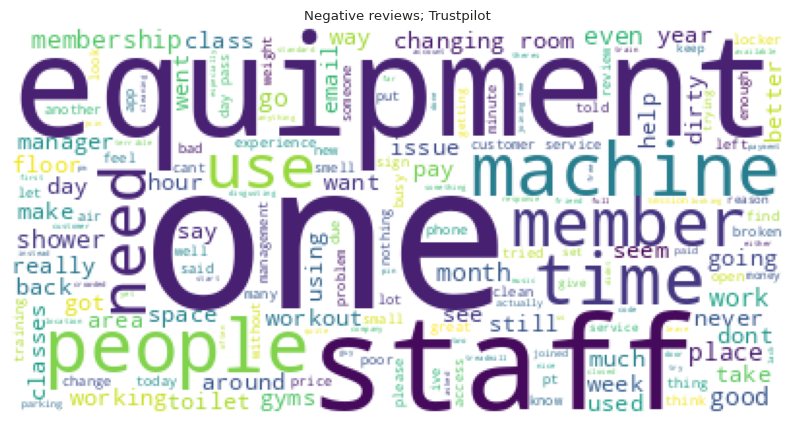

In [122]:
plt.figure(figsize=(10, 8))

word_cloud = WordCloud(
    background_color="white",
    # stopwords=set(),
    max_words=max_words_wc,
    random_state=SEED
)

# WordCloud analyses word frequency across all text, so it needs all words combined
word_cloud.generate(" ".join(neg_tokens))
plt.imshow(word_cloud)
plt.title("Negative reviews; Trustpilot")
plt.axis("off")

### 🔹 Insights

- The frequency distribution of all reviews and negative reviews in each dataset revealed the top 10 most repeated words.  

- Comparing both sources of reviews shows a strong overlap in common words:  
  - **All reviews:** 'classes', 'clean', 'equipment', 'friendly', 'good', 'great', 'machines', 'really', 'staff'`  
  - **Negative reviews:** `'equipment', 'get', 'like', 'machines', 'one', 'people', 'staff', 'time'  

- Comparing all reviews with negative reviews highlights that positive sentiment words like 'good' and 'great' disappear from the top words, as expected.  

- The main pain points appear to be related to **equipment/machines** and **staff/people**, reflecting common customer concerns.  

- The presence of noise words among high-frequency words illustrates the limitation of manually removing irrelevant tokens and the need for a more systematic or model-driven approach.

- Although this analysis provides preliminary insights, further exploration is needed to uncover deeper patterns.


# Initial Topic Modelling


Filtering all negative reviews to include only those from locations common to both datasets and using `BERTopic`, we aim to capture the main pain points across shared locations and extract the key topics and recurring issues affecting multiple sites.

In [123]:
len(common_locations)

319

In [124]:
processed_data_neg["location_name"].isna().sum()

np.int64(0)

In [125]:
# Negative reviews for shared loactions
processed_data_neg_comloc = processed_data_neg[
    processed_data_neg["location_name"].isin(common_locations)
]
processed_data_neg_comloc.shape

(4058, 7)

In [126]:
# common-location negative reviews (%)
processed_data_neg_comloc.shape[0]/processed_data_neg.shape[0]

0.6414796079671198

In [127]:
# Check the sum of negative reviews from each source equals to the total number of negative reviews
processed_data_neg_comloc[processed_data_neg_comloc["data_source"]=="trustpilot"].shape[0] + processed_data_neg_comloc[processed_data_neg_comloc["data_source"]=="google"].shape[0]

4058

In [128]:
processed_data_neg_comloc.head(1)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name,data_source
2,"[extremely, busy, fresh, air]","[extremely, busy, no, fresh, air]",extremely busy no fresh air,1,"Extremely busy, no fresh air.",sutton times square,trustpilot


## BERTopic

In [129]:
bertopic_config = config["topic_modelling"]["bertopic"]

### *focus: common locations - negative reviews*

In [130]:
# BERTopic needs a list of strings (one string per document (review))
neg_docs_comloc = [" ".join(tokens) for tokens in processed_data_neg_comloc["filtered_tokens"]]
len(neg_docs_comloc)

4058

In [131]:
# Initialise the model
bertopic_model = BERTopic(
    umap_model=umap_model,
    calculate_probabilities=bertopic_config["calculate_probabilities"],
    verbose=bertopic_config["verbose"]
)

In [132]:
# # Fit and transform on the data
# topic, probs = bertopic_model.fit_transform(neg_docs_comloc)

In [133]:
# # Configure your git identity
# !git config --global user.email "d.yarparvar@gmail.com"
# !git config --global user.name "Darya Yarparvar"

In [134]:
# # Define the path
# timestamp = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
# bertopic_model_path = f"{model_dir}/bertopic_model_comloc_{timestamp}"
# # Create directory
# os.makedirs(model_dir, exist_ok=True)
# # Save the model
# bertopic_model.save(bertopic_model_path)

In [135]:
# # Push
# !git add .
# !git commit -m "Update BERTopic model; negative reviews for locations common between the datasets."
# !git push

In [136]:
# Load the model
bertopic_model = BERTopic.load(f"{model_dir}/bertopic_model_comloc_20251224-181903")

In [137]:
# Setting the number of clusters
n_clusters = bertopic_config["n_clusters"]

In [138]:
# BERTopic results
bertopic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1704,-1_equipment_staff_machines_people,"[equipment, staff, machines, people, time, lik...",[first joined year ago clean equipment decent ...
1,0,200,0_air_conditioning_ac_aircon,"[air, conditioning, ac, aircon, hot, summer, h...",[plenty equipment often issues picked staff se...
2,1,160,1_membership_fee_month_account,"[membership, fee, month, account, joining, ema...",[advertised months membership joining fee join...
3,2,144,2_weights_weight_bench_dumbbells,"[weights, weight, bench, dumbbells, free, plat...",[lacks equipment chance stuff isnt matrix need...
4,3,128,3_class_classes_instructors_booked,"[class, classes, instructors, booked, instruct...","[impressed classes instructors taking class, f..."


In [139]:
# Top topics along with frequencies
bertopic_model.get_topic_info().head(n_clusters)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1704,-1_equipment_staff_machines_people,"[equipment, staff, machines, people, time, lik...",[first joined year ago clean equipment decent ...
1,0,200,0_air_conditioning_ac_aircon,"[air, conditioning, ac, aircon, hot, summer, h...",[plenty equipment often issues picked staff se...
2,1,160,1_membership_fee_month_account,"[membership, fee, month, account, joining, ema...",[advertised months membership joining fee join...
3,2,144,2_weights_weight_bench_dumbbells,"[weights, weight, bench, dumbbells, free, plat...",[lacks equipment chance stuff isnt matrix need...
4,3,128,3_class_classes_instructors_booked,"[class, classes, instructors, booked, instruct...","[impressed classes instructors taking class, f..."
5,4,116,4_parking_car_park_fine,"[parking, car, park, fine, free, fines, reg, t...","[free parking times, parking hours, free parki..."
6,5,107,5_music_loud_noise_headphones,"[music, loud, noise, headphones, hear, volume,...","[music please change music, simply gave done f..."
7,6,104,6_pass_code_day_pin,"[pass, code, day, pin, bought, qr, paid, help,...","[bought day pass pin time leave, paid day pass..."
8,7,104,7_equipment_busy_enough_wait,"[equipment, busy, enough, wait, small, equipme...","[enough equipment, enough equipment, busy equi..."
9,8,90,8_closed_open_christmas_days,"[closed, open, christmas, days, opening, day, ...",[visited today pm closed notification closed n...


In [140]:
# The most frequent topic
pd.DataFrame(bertopic_model.get_topic(0), columns=["representation", "probability"])

,representation,probability
0,air,0.06
1,conditioning,0.04
2,ac,0.03
3,aircon,0.03
4,hot,0.03
5,summer,0.02
6,heat,0.02
7,working,0.02
8,warm,0.02
9,temperature,0.02


In [141]:
# The second most frequent topic
pd.DataFrame(bertopic_model.get_topic(1), columns=["representation", "probability"])

,representation,probability
0,membership,0.05
1,fee,0.04
2,month,0.03
3,account,0.03
4,joining,0.03
5,email,0.03
6,cancel,0.03
7,app,0.03
8,charged,0.03
9,suspended,0.02


In [142]:
# Interactive visualisation of the topics
bertopic_model.visualize_topics()

In [143]:
# Bar chart of the topics including the top 5 words in each topic
bertopic_model.visualize_barchart()

In [144]:
# Heatmap(similarity matrix) of the topics
bertopic_model.visualize_heatmap()

In [145]:
# Hierarchical visualisation of the topics
hierarchical_topics = bertopic_model.hierarchical_topics(neg_docs_comloc)
bertopic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 52/52 [00:00<00:00, 77.41it/s]


BERTopic uses HDBSCAN for clustering. Topic -1 consists of the "outlier"s. It contains all the documents that the model could not confidently assign to a specific, dense cluster. Instead of forcing a document into a topic where it doesn't truly belong, BERTopic labels it as -1 to maintain the "purity" of other discovered topics.

Three reasons:

- Noise: too short, gibberish, stop words don't carry a clear theme

- Uniqueness: something so specific or rare that no other documents in the dataset share that theme

- Ambiguity: so many different topics in one document that the model can't decide which one is the primary fit

Topic -1 has 1704 documents. This is a significant portion of negative reviews (~42%)

  - To keep other topics clean, we should leave topic -1 as it is. This ensures that other topics are highly accurate and relevant.

  - On the other hand we might be losing too much information. We can use `reduce_outliers` function in BERTopic to force the outlier documents into the closest matching topic, or we can tune the `min_cluster_size` to be smaller to catch more niche topics.

**mapping the outliers and reducing the number of clusters to 10**

In [146]:
# Set the number of topics to 10 cluster
n_clusters = bertopic_config["n_clusters"]
n_bertopics = n_clusters
# n_bertopics = n_clusters + 1 if the outliers are not mapped to the most similar topic

# Calculate the distributions (find the closest topic for outliers)
probabilities = bertopic_model.approximate_distribution(neg_docs_comloc)
topics = bertopic_model.topics_

# Use distributions to map outliers to the most similar topic
new_topics = bertopic_model.reduce_outliers(neg_docs_comloc, topics, strategy=bertopic_config["outlier_handling"])

# Update the model with these new assignments
bertopic_model.update_topics(neg_docs_comloc, topics=new_topics)

# Further reduce the number of topics
bertopic_model.reduce_topics(neg_docs_comloc, nr_topics=n_bertopics)

# Access updated topics
reduced_ten_topics = bertopic_model.topics_

100%|██████████| 5/5 [00:03<00:00,  1.30it/s]
2026-01-18 10:03:45,013 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
2026-01-18 10:03:46,134 - BERTopic - Topic reduction - Reducing number of topics
2026-01-18 10:03:46,201 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-18 10:03:46,940 - BERTopic - Representation - Completed ✓
2026-01-18 10:03:46,951 - BERTopic - Topic reduction - Reduced number of topics from 53 to 10


In [147]:
# BERTopic results
bertopic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,0,1393,0_membership_air_staff_equipment,"[membership, air, staff, equipment, one, get, ...",[plenty equipment across floors issues air con...
1,1,1165,1_staff_class_classes_one,"[staff, class, classes, one, toilets, time, da...",[standard get pay since ive going last months ...
2,2,872,2_equipment_parking_weights_people,"[equipment, parking, weights, people, staff, o...",[year huge array equipment staff polite place ...
3,3,185,3_cold_dirty_manager_showers,"[cold, dirty, manager, showers, equipment, mac...","[showers cold, coming since like september las..."
4,4,146,4_cleaning_staff_equipment_pin,"[cleaning, staff, equipment, pin, stations, cl...",[two cleaning stations entire never blue roll ...


In [148]:
# Top topics along with frequencies
bertopic_model.get_topic_info().sort_values(by="Count", ascending=False).head(n_clusters)

,Topic,Count,Name,Representation,Representative_Docs
0,0,1393,0_membership_air_staff_equipment,"[membership, air, staff, equipment, one, get, ...",[plenty equipment across floors issues air con...
1,1,1165,1_staff_class_classes_one,"[staff, class, classes, one, toilets, time, da...",[standard get pay since ive going last months ...
2,2,872,2_equipment_parking_weights_people,"[equipment, parking, weights, people, staff, o...",[year huge array equipment staff polite place ...
3,3,185,3_cold_dirty_manager_showers,"[cold, dirty, manager, showers, equipment, mac...","[showers cold, coming since like september las..."
4,4,146,4_cleaning_staff_equipment_pin,"[cleaning, staff, equipment, pin, stations, cl...",[two cleaning stations entire never blue roll ...
5,5,114,5_music_loud_classes_hear,"[music, loud, classes, hear, noise, headphones...","[music please change music, simply gave done f..."
6,6,76,6_cleaning_sweat_equipment_towels,"[cleaning, sweat, equipment, towels, clean, ma...",[disgusting ever cleaning products tissues cle...
7,7,61,7_cable_machines_ceo_machine,"[cable, machines, ceo, machine, genocide, miss...",[could great sadly issues make less machines c...
8,8,25,8_changing_rooms_room_dirty,"[changing, rooms, room, dirty, disgusting, nev...","[bad smell changing room, dirty changing room,..."
9,9,21,9_crowded_many_people_space,"[crowded, many, people, space, time, feels, su...","[crowded, crowded, crowded]"


In [149]:
# Interactive visualisation of the topics
bertopic_model.visualize_topics()

In [150]:
# Bar chart of the topics including the top 5 words in each topic
bertopic_model.visualize_barchart()

In [151]:
# Heatmap(similarity matrix) of the topics
bertopic_model.visualize_heatmap()

In [152]:
# Hierarchical visualisation of the topics
hierarchical_topics = bertopic_model.hierarchical_topics(neg_docs_comloc)
bertopic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 9/9 [00:00<00:00, 34.42it/s]


Mapping the outliers to the most similar topic **AND** reducing the number of topics to 10 at the same time resulted in diluted and impure topics. Therefore, we do not combine these methods and just stick with one at a time and compare the outcome.

Fisrt, we leave the outliers alone and we do not enforce the model to assign them to any other topics. We only reduce the number of clusters to 10.

**reducing the number of clusters to 10**

In [153]:
# Set the number of topics to 10 cluster
n_clusters = bertopic_config["n_clusters"]
# +1 since the outliers are not mapped to the most similar topic, therefore on cluster will be assigned to them
n_bertopics = n_clusters + 1

# Load the model
bertopic_model = BERTopic.load(f"{model_dir}/bertopic_model_comloc_20251224-181903")

# Further reduce the number of topics
bertopic_model.reduce_topics(neg_docs_comloc, nr_topics=n_bertopics)

# Access updated topics
reduced_ten_topics = bertopic_model.topics_

2026-01-18 10:03:51,362 - BERTopic - Topic reduction - Reducing number of topics
2026-01-18 10:03:51,439 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-18 10:03:52,409 - BERTopic - Representation - Completed ✓
2026-01-18 10:03:52,419 - BERTopic - Topic reduction - Reduced number of topics from 54 to 11


In [154]:
# BERTopic results
bertopic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1704,-1_equipment_staff_machines_people,"[equipment, staff, machines, people, one, time...",[first joined year ago clean equipment decent ...
1,0,690,0_air_showers_water_cold,"[air, showers, water, cold, hot, conditioning,...",[hednesford like sauna air conditioning hasnt ...
2,1,688,1_equipment_machines_music_weights,"[equipment, machines, music, weights, people, ...",[ive member years great start whilst seen cont...
3,2,585,2_class_classes_membership_day,"[class, classes, membership, day, get, pass, e...",[disappointed booked one day pass used book cl...
4,3,116,3_parking_car_park_free,"[parking, car, park, free, fine, fines, reg, t...","[free parking times, get free parking car park..."


In [155]:
# Top topics along with frequencies
bertopic_model.get_topic_info().sort_values(by="Count", ascending=False).head(n_clusters)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1704,-1_equipment_staff_machines_people,"[equipment, staff, machines, people, one, time...",[first joined year ago clean equipment decent ...
1,0,690,0_air_showers_water_cold,"[air, showers, water, cold, hot, conditioning,...",[hednesford like sauna air conditioning hasnt ...
2,1,688,1_equipment_machines_music_weights,"[equipment, machines, music, weights, people, ...",[ive member years great start whilst seen cont...
3,2,585,2_class_classes_membership_day,"[class, classes, membership, day, get, pass, e...",[disappointed booked one day pass used book cl...
4,3,116,3_parking_car_park_free,"[parking, car, park, free, fine, fines, reg, t...","[free parking times, get free parking car park..."
5,4,89,4_manager_staff_rude_member,"[manager, staff, rude, member, reviews, voice,...",[avoid want exercise friendly clean space mana...
6,5,61,5_never_go_worst_past,"[never, go, worst, past, didnt, dont, know, na...","[never, never, never]"
7,6,53,6_busy_crowded_overcrowded_way,"[busy, crowded, overcrowded, way, time, many, ...","[busy, busy, busy]"
8,7,44,7_wifi_signal_terrible_work,"[wifi, signal, terrible, work, place, months, ...",[hard install working wifi open years still wi...
9,8,16,8_expensive_avoid_involved_sell,"[expensive, avoid, involved, sell, overpriced,...","[expensive student uk, expensive, expensive]"


In [156]:
# Interactive visualisation of the topics
bertopic_model.visualize_topics()

In [157]:
# Bar chart of the topics including the top 5 words in each topic
bertopic_model.visualize_barchart()

In [158]:
# Heatmap(similarity matrix) of the topics
bertopic_model.visualize_heatmap()

In [159]:
# Hierarchical visualisation of the topics
hierarchical_topics = bertopic_model.hierarchical_topics(neg_docs_comloc)
bertopic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 9/9 [00:00<00:00, 132.15it/s]


Now, we only map the outliers to the most similar topic without reducing the number of clusters to 10.

**mapping the outliers to the most similar topic**

In [160]:
# Load the model
bertopic_model = BERTopic.load(f"{model_dir}/bertopic_model_comloc_20251224-181903")

# Calculate the distributions (find the closest topic for outliers)
probabilities = bertopic_model.approximate_distribution(neg_docs_comloc)
topics = bertopic_model.topics_

# Use distributions to map outliers to the most similar topic
new_topics = bertopic_model.reduce_outliers(neg_docs_comloc, topics, strategy=bertopic_config["outlier_handling"])

# Update the model with these new assignments
bertopic_model.update_topics(neg_docs_comloc, topics=new_topics)

100%|██████████| 5/5 [00:06<00:00,  1.38s/it]
2026-01-18 10:04:07,088 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [161]:
# BERTopic results
bertopic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,0,225,0_air_conditioning_hot_ac,"[air, conditioning, hot, ac, aircon, summer, h...",[plenty equipment often issues picked staff se...
1,1,194,1_membership_fee_month_account,"[membership, fee, month, account, email, joini...",[advertised months membership joining fee join...
2,2,206,2_weights_weight_bench_free,"[weights, weight, bench, free, dumbbells, plat...",[lacks equipment chance stuff isnt matrix need...
3,3,154,3_class_classes_instructors_booked,"[class, classes, instructors, booked, cancelle...","[impressed classes instructors taking class, f..."
4,4,118,4_parking_car_park_fine,"[parking, car, park, fine, free, fines, reg, t...","[free parking times, parking hours, free parki..."


In [162]:
# Top topics along with frequencies
bertopic_model.get_topic_info().sort_values(by="Count", ascending=False).head(n_clusters)

,Topic,Count,Name,Representation,Representative_Docs
0,0,225,0_air_conditioning_hot_ac,"[air, conditioning, hot, ac, aircon, summer, h...",[plenty equipment often issues picked staff se...
2,2,206,2_weights_weight_bench_free,"[weights, weight, bench, free, dumbbells, plat...",[lacks equipment chance stuff isnt matrix need...
1,1,194,1_membership_fee_month_account,"[membership, fee, month, account, email, joini...",[advertised months membership joining fee join...
20,20,188,20_equipment_machines_people_one,"[equipment, machines, people, one, area, weigh...",[ive member years great start whilst seen cont...
17,17,173,17_changing_toilets_toilet_broken,"[changing, toilets, toilet, broken, staff, man...",[unfortunately management rather post social m...
7,7,165,7_equipment_busy_enough_needs,"[equipment, busy, enough, needs, use, good, sm...","[enough equipment, enough equipment, busy equi..."
3,3,154,3_class_classes_instructors_booked,"[class, classes, instructors, booked, cancelle...","[impressed classes instructors taking class, f..."
21,21,127,21_staff_member_manager_people,"[staff, member, manager, people, rude, pt, mem...",[avoid want exercise friendly clean space dele...
6,6,121,6_pass_code_day_pin,"[pass, code, day, pin, bought, get, help, paid...","[bought day pass pin time leave, paid day pass..."
10,10,120,10_smell_smells_smelly_ventilation,"[smell, smells, smelly, ventilation, bad, stin...",[smells bad eveywhere place breathe womens toi...


In [163]:
# Words representing the top topics
bertopic_model.get_topic_info().sort_values(by="Count", ascending=False).head(n_clusters)["Representation"].to_list()

[['air',
  'conditioning',
  'hot',
  'ac',
  'aircon',
  'summer',
  'heat',
  'working',
  'temperature',
  'warm'],
 ['weights',
  'weight',
  'bench',
  'free',
  'dumbbells',
  'plates',
  'benches',
  'equipment',
  'press',
  'people'],
 ['membership',
  'fee',
  'month',
  'account',
  'email',
  'joining',
  'cancel',
  'app',
  'charged',
  'pay'],
 ['equipment',
  'machines',
  'people',
  'one',
  'area',
  'weights',
  'like',
  'place',
  'staff',
  'members'],
 ['changing',
  'toilets',
  'toilet',
  'broken',
  'staff',
  'management',
  'rooms',
  'showers',
  'years',
  'equipment'],
 ['equipment',
  'busy',
  'enough',
  'needs',
  'use',
  'good',
  'small',
  'equipments',
  'time',
  'broken'],
 ['class',
  'classes',
  'instructors',
  'booked',
  'cancelled',
  'instructor',
  'spin',
  'time',
  'book',
  'membership'],
 ['staff',
  'member',
  'manager',
  'people',
  'rude',
  'pt',
  'members',
  'management',
  'reviews',
  'voice'],
 ['pass',
  'code',
  '

In [164]:
# The most frequent topic
pd.DataFrame(bertopic_model.get_topic(0), columns=["representation", "probability"])

,representation,probability
0,air,0.06
1,conditioning,0.04
2,hot,0.03
3,ac,0.03
4,aircon,0.03
5,summer,0.02
6,heat,0.02
7,working,0.02
8,temperature,0.02
9,warm,0.02


In [165]:
# The second most frequent topic
pd.DataFrame(bertopic_model.get_topic(1), columns=["representation", "probability"])

,representation,probability
0,membership,0.05
1,fee,0.04
2,month,0.03
3,account,0.03
4,email,0.03
5,joining,0.03
6,cancel,0.03
7,app,0.02
8,charged,0.02
9,pay,0.02


In [166]:
# Interactive visualisation of the topics
bertopic_model.visualize_topics()

In [167]:
# Bar chart of the topics including the top 5 words in each topic
bertopic_model.visualize_barchart()

In [168]:
# Heatmap(similarity matrix) of the topics
bertopic_model.visualize_heatmap()

In [169]:
# Hierarchical visualisation of the topics
hierarchical_topics = bertopic_model.hierarchical_topics(neg_docs_comloc)
bertopic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 52/52 [00:00<00:00, 63.96it/s]


Reducing the number of clusters alone did not change the proportion of outliers.

**Mapping outliers to the most similar topic** is a more effective approach. This allows all available data to be used without creating overly broad or impure topics, unlike forcing the model to fit everything into a fixed number of clusters.

### 🔹 Insights

The top topics from negative reviews at locations common to both datasets capture shared, recurring pain points across sites:
1. Air conditioning and temperature issues, making the gym uncomfortable during hot weather (5.5%)
    - words: air, conditioning, hot, ac, aircon, summer, heat, working, temperature, warm

2. Frustrations with insufficient weights, benches, and general equipment availability (5.1%)
    - words: weights, weight, bench, free, dumbbells, plates, benches, equipment, press, people

3. Membership fees, account management, app issues, and subscription problems (4.8%)
    - words: membership, fee, month, account, email, joining, cancel, app, charged, pay

4. Equipment, machines, weights, and area management issues (4.6%)
    - words: equipment, machines, people, one, area, weights, like, place, staff, members

5. Problems with broken or poorly maintained toilets, showers, and changing facilities (4.3%)
    - words: changing, toilets, toilet, broken, staff, management, rooms, showers, years, equipment

6. Equipment being occupied, not enough, or broken (4.1%)
    - words: equipment, busy, enough, needs, use, good, small, equipments, time, broken

7. Issues with class scheduling, cancellations, and instructors (3.8%)
    - words: class, classes, instructors, booked, cancelled, instructor, spin, time, book, membership

8. Unprofessional behaviour of staff or management (3.1%)
    - words: staff, member, manager, people, rude, pt, members, management, reviews, voice

9. Problems with day passes, access codes, and PINs (3.0%)
    - words: pass, code, day, pin, bought, get, help, paid, email, qr

10. Bad smells, poor ventilation, and dirty facilities (3.0%)
    - words: smell, smells, smelly, ventilation, bad, stinks, air, dirty, odour, changing


- In the intertopic distance map, overlapping clusters indicate similar semantic content and likely represent variations of the same core complaint themes. The central region, which contains several medium/large topics, reflects the dominant categories of customer dissatisfaction. Most of the top 10 topics lies inside this central region, indicating that these leading topics are concentrated around a single dominant complaint family rather than covering a broad diversity of issues.


- In a well-performing BERTopic model, we expect strong internal coherence within each topic and weak similarity between different topics, indicating clean semantic separation. In this heatmap, dark blue squares highlight topics that are nearly identical, suggesting areas where we could merge categories to simplify the results. Light green areas show distinct, unrelated problems. The presence of some medium similarity is not a modelling flaw but a reflection of real-world, multidimensional complaints.

- The dendrogram indicates that if all reviews are forced into just 3 clusters, they collapse into 3 broad themes centred on:
  - membership, class, staff, classes, parking
  - equipment, machines, people, one, weights
  - showers, shower, cold, water, hot


## Frequency Distribution

### *focus: worst locations - negative reviews*

Focusing on locations with the highest number of negative reviews allows us to prioritise interventions and address the sites causing the greatest customer dissatisfaction.

Listing the top 20 locations with the highest number of negative reviews for each dataset:

In [170]:
n_worst_locations = config["focus_strategy"]["n_worst_locations"]

In [171]:
# Get top locations with most negative reviews - Truspilot
worst_locations_tp = processed_data_neg_tp.groupby("location_name")["filtered_tokens"].count().sort_values(ascending=False).head(n_worst_locations).reset_index()
worst_locations_tp

,location_name,filtered_tokens
0,nan,1291
1,leicester walnut street,50
2,345,45
3,london enfield,23
4,london stratford,22
5,burnham,20
6,london ilford,18
7,london bermondsey,18
8,maidenhead,16
9,london finchley,16


In [172]:
# Get top locations with most negative reviews - Google
worst_locations_g = processed_data_neg_g.groupby("location_name")["filtered_tokens"].count().sort_values(ascending=False).head(n_worst_locations).reset_index()
worst_locations_g

,location_name,filtered_tokens
0,london stratford,59
1,london woolwich,26
2,london canary wharf,26
3,london enfield,25
4,london swiss cottage,24
5,london palmers green,22
6,london leytonstone,21
7,birmingham city centre,21
8,new barnet,20
9,wakefield,19


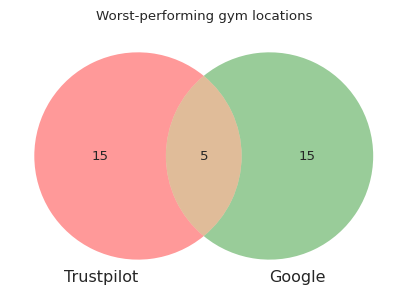

In [173]:
# Plot Venn diagram
plt.figure(figsize=(5, 5))
venn = venn2(
    [set(worst_locations_tp["location_name"]), set(worst_locations_g["location_name"])],
    set_labels=("Trustpilot", "Google"),
)

plt.title("Worst-performing gym locations")
plt.show()

### 🔹 Insights

Focusing on locations with the highest number of negative reviews for each dataset separately:

  - **7 common locations** between datasets: 'london seven sisters', 'london stratford', 'london swiss cottage', 'london hayes', 'london enfield', 'new barnet', 'london bermondsey'
  - **13 locations only in Trustpilot:** 'london finchley', 'york', 'london bromley', 'london hammersmith palais', 'burnham', 'northwich', 'birmingham beaufort park', 'leicester walnut street', 'nan', 'telford', 'london ilford', '345', 'maidenhead', 'basildon'
  - **13 locations only in Google:** 'london woolwich', 'walsall crown wharf', 'manchester exchange quay', 'birmingham city centre', 'wakefield', 'london leytonstone', 'london hoxton', 'bradford thornbury', 'sutton times square', 'london canary wharf', 'nottingham colwick', 'london palmers green', 'bachenbülach', 'peterborough serpentine'


Most of the worst-performing locations (65%) are not shared between the two datasets. This means that focusing only on common worst-performing locations would miss many high-complaint sites.

By merging all negative reviews from both datasets, we capture all locations with significant dissatisfaction, assuming that the number of negative reviews is a reasonable proxy for identifying the “worst-performing” locations.

Identifying the top 30 locations with the highest number of negative reviews:

In [174]:
n_common_worst_locations = config["focus_strategy"]["n_common_worst_locations"]

In [175]:
# Group all negative reviews based on their location
grouped_processed_data_neg = processed_data_neg.groupby(["location_name"])["filtered_tokens"].count().sort_values(ascending=False).reset_index()
grouped_processed_data_neg.head(n_common_worst_locations)

,location_name,filtered_tokens
0,nan,1291
1,london stratford,81
2,leicester walnut street,61
3,london enfield,48
4,345,45
5,london swiss cottage,39
6,birmingham city centre,35
7,london seven sisters,34
8,london bermondsey,34
9,new barnet,34


In [176]:
# Get the top 30 locations with the highest number of negative reviews - Overall
worst_locations = grouped_processed_data_neg.head(n_common_worst_locations)["location_name"]
worst_locations

,location_name
0,nan
1,london stratford
2,leicester walnut street
3,london enfield
4,345
5,london swiss cottage
6,birmingham city centre
7,london seven sisters
8,london bermondsey
9,new barnet


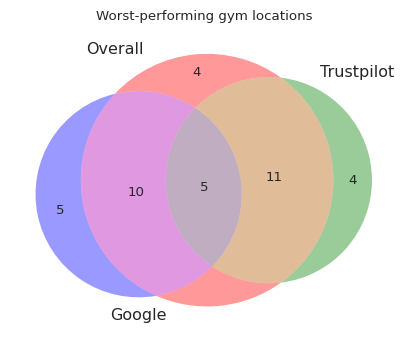

In [177]:
# Plot Venn diagram
plt.figure(figsize=(5, 5))
venn = venn3(
    [set(worst_locations), set(worst_locations_tp["location_name"]), set(worst_locations_g["location_name"])],
    set_labels=("Overall", "Trustpilot", "Google"),
)

plt.title("Worst-performing gym locations")
plt.show()

In [178]:
# Convert to list
worstloc = worst_locations.tolist()

In [179]:
# Get worst locations from each dataset
tp_worst_locations = set(worst_locations_tp["location_name"])
g_worst_locations = set(worst_locations_g["location_name"])

# Find common locations
common_locations = list(tp_worst_locations & g_worst_locations)

# Find locations only in Trustpilot
only_tp = list(tp_worst_locations - g_worst_locations)

# Find locations only in Google
only_g = list(g_worst_locations - tp_worst_locations)

# Print results
print(
    f"\n Overall 30 worst locations: \n{worst_locations}"
    f"\n Common worst 20 locations: \n{common_locations}"
    f"\n Only in Trustpilot: \n{only_tp}"
    f"\n Only in Google: \n{only_g}"
)


 Overall 30 worst locations: 
0                           nan
1              london stratford
2       leicester walnut street
3                london enfield
4                           345
5          london swiss cottage
6        birmingham city centre
7          london seven sisters
8             london bermondsey
9                    new barnet
10                 london hayes
11           bradford thornbury
12          london canary wharf
13          walsall crown wharf
14                      burnham
15              london finchley
16    london hammersmith palais
17          london muswell hill
18           nottingham colwick
19     birmingham beaufort park
20                    wakefield
21                     basildon
22              london woolwich
23                   maidenhead
24                london hoxton
25           london leytonstone
26            london park royal
27               london bromley
28               london holborn
29               london beckton
Name: loc

### 🔹 Insights

The **overall 30 worst-performing locations** based on the total number of negative reviews:  
  1. nan  
  2. london stratford  
  3. leicester walnut street  
  4. london enfield  
  5. 345  
  6. london swiss cottage  
  7. birmingham city centre  
  8. london seven sisters  
  9. london bermondsey  
  10. new barnet  
  11. london hayes  
  12. bradford thornbury  
  13. london canary wharf  
  14. walsall crown wharf  
  15. burnham  
  16. london finchley  
  17. london hammersmith palais  
  18. london muswell hill  
  19. nottingham colwick  
  20. birmingham beaufort park  
  21. wakefield  
  22. basildon  
  23. london woolwich  
  24. maidenhead  
  25. london hoxton  
  26. london leytonstone  
  27. london park royal  
  28. london bromley  
  29. london holborn  
  30. london beckton


  - City counts summary (excluding nan and 345):  
    London: 17  
    Birmingham: 2
    Leicester: 1  
    Bradford: 1  
    Walsall: 1  
    Nottingham: 1  
    Burnham: 1  
    Basildon: 1  
    New Barnet: 1  
    Maidenhead: 1

  - 1291 negative reviews lack location information, representing missing valuable context for analysis. This limits the ability to link complaints to specific locations.


Extracting negative reviews for the overall 30 worst-performing locations for each dataset:

In [180]:
# Trustpilot - group by location
grouped_processed_data_neg_tp = processed_data_neg_tp.groupby(["location_name"])["filtered_tokens"].count().sort_values(ascending=False).reset_index()
grouped_processed_data_neg_worstloc_tp = grouped_processed_data_neg_tp[grouped_processed_data_neg_tp["location_name"].isin(worstloc)]
grouped_processed_data_neg_worstloc_tp

,location_name,filtered_tokens
0,nan,1291
1,leicester walnut street,50
2,345,45
3,london enfield,23
4,london stratford,22
5,burnham,20
7,london bermondsey,18
8,maidenhead,16
9,london finchley,16
11,london seven sisters,16


In [181]:
# Google - group by location
grouped_processed_data_neg_g = processed_data_neg_g.groupby(["location_name"])["filtered_tokens"].count().sort_values(ascending=False).reset_index()
grouped_processed_data_neg_worstloc_g = grouped_processed_data_neg_g[grouped_processed_data_neg_g["location_name"].isin(worstloc)]
grouped_processed_data_neg_worstloc_g

,location_name,filtered_tokens
0,london stratford,59
1,london woolwich,26
2,london canary wharf,26
3,london enfield,25
4,london swiss cottage,24
6,london leytonstone,21
7,birmingham city centre,21
8,new barnet,20
9,wakefield,19
11,bradford thornbury,19


In [182]:
# Overall - group by location and data source to retain the data source info
grouped_processed_data_neg = processed_data_neg.groupby(["location_name", "data_source"])["filtered_tokens"].count().sort_values(ascending=False).reset_index()
grouped_processed_data_neg_worstloc = grouped_processed_data_neg[grouped_processed_data_neg["location_name"].isin(worstloc)]
grouped_processed_data_neg_worstloc

,location_name,data_source,filtered_tokens
0,nan,trustpilot,1291
1,london stratford,google,59
2,leicester walnut street,trustpilot,50
3,345,trustpilot,45
4,london woolwich,google,26
5,london canary wharf,google,26
6,london enfield,google,25
7,london swiss cottage,google,24
8,london enfield,trustpilot,23
10,london stratford,trustpilot,22


In [183]:
# Overall - only group by location - to check
grouped_processed_data_neg_2 = processed_data_neg.groupby(["location_name"])["filtered_tokens"].count().sort_values(ascending=False).reset_index()
grouped_processed_data_neg_2[grouped_processed_data_neg_2["location_name"].isin(worstloc)]

,location_name,filtered_tokens
0,nan,1291
1,london stratford,81
2,leicester walnut street,61
3,london enfield,48
4,345,45
5,london swiss cottage,39
6,birmingham city centre,35
7,london seven sisters,34
8,london bermondsey,34
9,new barnet,34


In [184]:
# Trustpilot
processed_data_neg_worstloc_tp = processed_data_neg_tp[processed_data_neg_tp["location_name"].isin(worstloc)]
# Google
processed_data_neg_worstloc_g = processed_data_neg_g[processed_data_neg_g["location_name"].isin(worstloc)]
# Overall
processed_data_neg_worstloc = processed_data_neg[processed_data_neg["location_name"].isin(worstloc)]

In [185]:
processed_data_neg_worstloc_tp.head(3)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name,data_source
35,"[wanted, set, another, debit, card, direct, de...","[all, i, wanted, to, do, was, set, up, another...",all i wanted to do was set up another debit ca...,1,All I wanted to do was set up another debit ca...,nan,trustpilot
36,"[ever, downgrade, membership, core, plus, canc...","[what, ever, you, do, don, t, downgrade, your,...",what ever you do don t downgrade your membersh...,1,What ever you do don’t downgrade your membersh...,nan,trustpilot
38,"[poor, parking, enough, kit, unhelpful, traine...","[poor, parking, not, enough, kit, unhelpful, t...",poor parking not enough kit unhelpful trainers...,2,"Poor parking, not enough kit, unhelpful traine...",nan,trustpilot


In [186]:
processed_data_neg_worstloc_g.head(3)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name,data_source
7,"[way, hot, even, workout, windows, open, ac, b...","[this, gym, is, way, too, hot, to, even, worko...",this gym is way too hot to even workout in the...,2,This gym is way too hot to even workout in. Th...,new barnet,google
65,"[airconditioning, doesnt, work]","[airconditioning, doesnt, work]",airconditioning doesnt work,1,Air-conditioning doesnt work,new barnet,google
168,"[staff, allowed, blame, annoying, people, hoxt...","[is, pure, gym, staff, allowed, to, blame, or,...",is pure gym staff allowed to blame or annoying...,1,Is pure gym staff allowed to blame or annoying...,london hoxton,google


In [187]:
processed_data_neg_worstloc.head(3)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name,data_source
35,"[wanted, set, another, debit, card, direct, de...","[all, i, wanted, to, do, was, set, up, another...",all i wanted to do was set up another debit ca...,1,All I wanted to do was set up another debit ca...,nan,trustpilot
36,"[ever, downgrade, membership, core, plus, canc...","[what, ever, you, do, don, t, downgrade, your,...",what ever you do don t downgrade your membersh...,1,What ever you do don’t downgrade your membersh...,nan,trustpilot
38,"[poor, parking, enough, kit, unhelpful, traine...","[poor, parking, not, enough, kit, unhelpful, t...",poor parking not enough kit unhelpful trainers...,2,"Poor parking, not enough kit, unhelpful traine...",nan,trustpilot


In [188]:
# worst-location negative reviews (%)
processed_data_neg_worstloc.shape[0]/processed_data_neg.shape[0]

0.35551691432184634

In [189]:
# Trustpilot
neg_tokens_worstloc_tp = [token for tokens in processed_data_neg_worstloc_tp["filtered_tokens"] for token in tokens]
# Google
neg_tokens_worstloc_g = [token for tokens in processed_data_neg_worstloc_g["filtered_tokens"] for token in tokens]
# Overall
neg_tokens_worstloc = [token for tokens in processed_data_neg_worstloc["filtered_tokens"] for token in tokens]

In [190]:
# Trustpilot
fdist_neg_worstloc_tp = FreqDist(neg_tokens_worstloc_tp)
# Google
fdist_neg_worstloc_g = FreqDist(neg_tokens_worstloc_g)
# Overall
fdist_neg_worstloc = FreqDist(neg_tokens_worstloc)

**Trsutpilot**

In [191]:
most_common_neg_worstloc_tp = pd.DataFrame(
    fdist_neg_worstloc_tp.most_common(n_most_common),
    columns=["token", "frequency"]
)

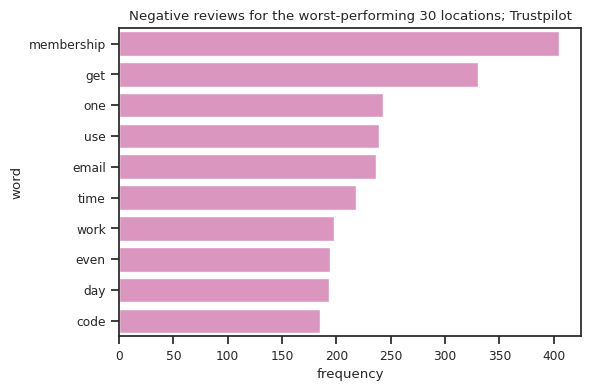

In [192]:
plt.figure(figsize=(6, 4))

# # Plot a histogram for each feature
sns.barplot(data=most_common_neg_worstloc_tp, y="token", x="frequency", color=palette_set2[3])

plt.title("Negative reviews for the worst-performing 30 locations; Trustpilot")
plt.ylabel("word")

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

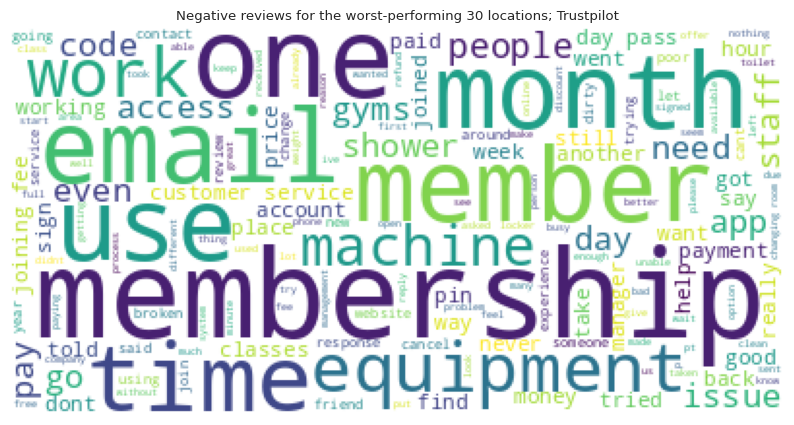

In [193]:
plt.figure(figsize=(10, 8))

word_cloud = WordCloud(
    background_color="white",
    # stopwords=set(),
    max_words=max_words_wc,
    random_state=SEED
)

# WordCloud analyses word frequency across all text, so it needs all words combined
word_cloud.generate(" ".join(neg_tokens_worstloc_tp))
plt.imshow(word_cloud)
plt.title("Negative reviews for the worst-performing 30 locations; Trustpilot")
plt.axis("off")

**Google**

In [194]:
most_common_neg_worstloc_g = pd.DataFrame(
    fdist_neg_worstloc_g.most_common(n_most_common),
    columns=["token", "frequency"]
)

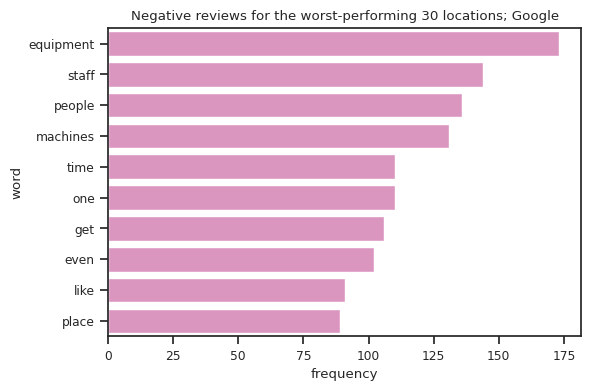

In [195]:
plt.figure(figsize=(6, 4))

# # Plot a histogram for each feature
sns.barplot(data=most_common_neg_worstloc_g, y="token", x="frequency", color=palette_set2[3])

plt.title("Negative reviews for the worst-performing 30 locations; Google")
plt.ylabel("word")

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

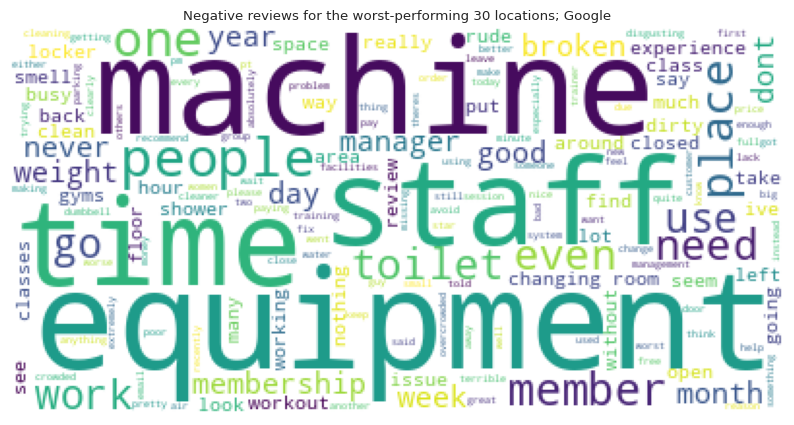

In [196]:
plt.figure(figsize=(10, 8))

word_cloud = WordCloud(
    background_color="white",
    # stopwords=set(),
    max_words=max_words_wc,
    random_state=SEED
)

# WordCloud analyses word frequency across all text, so it needs all words combined
word_cloud.generate(" ".join(neg_tokens_worstloc_g))
plt.imshow(word_cloud)
plt.title("Negative reviews for the worst-performing 30 locations; Google")
plt.axis("off")

**Overall**

In [197]:
most_common_neg_worstloc = pd.DataFrame(
    fdist_neg_worstloc.most_common(n_most_common),
    columns=["token", "frequency"]
)

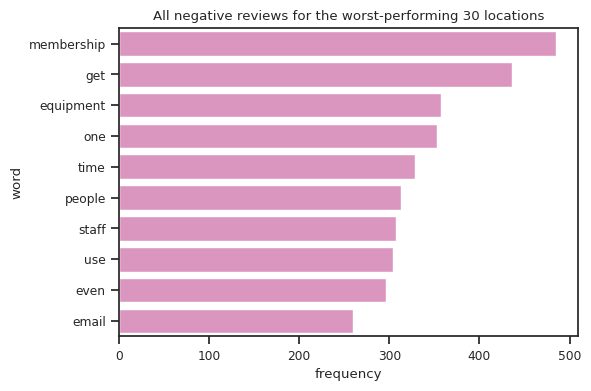

In [198]:
plt.figure(figsize=(6, 4))

# # Plot a histogram for each feature
sns.barplot(data=most_common_neg_worstloc, y="token", x="frequency", color=palette_set2[3])

plt.title("All negative reviews for the worst-performing 30 locations")
plt.ylabel("word")

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

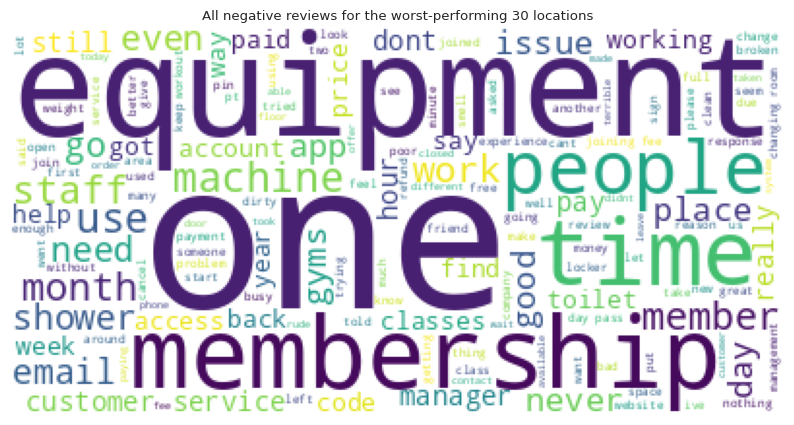

In [199]:
plt.figure(figsize=(10, 8))

word_cloud = WordCloud(
    background_color="white",
    # stopwords=set(),
    max_words=max_words_wc,
    random_state=SEED
)

# WordCloud analyses word frequency across all text, so it needs all words combined
word_cloud.generate(" ".join(neg_tokens_worstloc))
plt.imshow(word_cloud)
plt.title("All negative reviews for the worst-performing 30 locations")
plt.axis("off")

In [200]:
# Common high-frequency words between two datasets (negatiove reviews at worst 30 locations)
set(most_common_neg_worstloc_tp["token"]) & set(most_common_neg_worstloc_g["token"])

{'even', 'get', 'one', 'time'}

In [201]:
# Common high-frequency words between Trustpilot & Combined (negatiove reviews at worst 30 locations)
set(most_common_neg_worstloc["token"]) & set(most_common_neg_worstloc_tp["token"])

{'email', 'even', 'get', 'membership', 'one', 'time', 'use'}

In [202]:
# Common high-frequency words between Google & Combined (negatiove reviews at worst 30 locations)
set(most_common_neg_worstloc["token"]) & set(most_common_neg_worstloc_g["token"])

{'equipment', 'even', 'get', 'one', 'people', 'staff', 'time'}

### 🔹 Insights

"Membership" emerges as the dominant term, followed by issues related to "equipment", “time”, “people/staff”, and “email” indicating primary pain points at problematic sites. Some low-value terms such as "get" remain in the frequency list.

Further refinement of the custom stop-word list would be beneficial to increase the signal-to-noise ratio.

While the bar chart provides a precise quantitative ranking, the word cloud's internal preprocessing and layout algorithm offer a qualitative overview where spatial fit and word length can skew the perceived dominance of terms.


## BERTopic


Next, using `BERTopic` on all negative reviews from the worst-performing locations we aim to identify the top topics and recurring pain points across sites with the highest complaint volumes.

In [203]:
bertopic_config = config["topic_modelling"]["bertopic"]

### *focus: worst locations - negative reviews*

Focusing on locations with the highest number of negative reviews allows us to prioritise interventions and address the sites causing the greatest customer dissatisfaction.

In [204]:
# BERTopic needs a list of strings (one string per document (review))
neg_docs_worstloc = [" ".join(tokens) for tokens in processed_data_neg_worstloc["filtered_tokens"]]
len(neg_docs_worstloc)

2249

In [205]:
# Initialise the model
bertopic_model = BERTopic(
    umap_model=umap_model,
    calculate_probabilities=bertopic_config["calculate_probabilities"],
    verbose=bertopic_config["verbose"]
)

In [206]:
# # Fit and transform on the data
# topic, probs = bertopic_model.fit_transform(neg_docs_worstloc)

In [207]:
# # Define the path
# timestamp = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
# bertopic_model_path = f"{model_dir}/bertopic_model_worstloc_{timestamp}"
# # Create directory
# os.makedirs(model_dir, exist_ok=True)
# # Save the model
# bertopic_model.save(bertopic_model_path)

In [208]:
# # Push
# !git add .
# !git commit -m "Update BERTopic model for top 30 location with most negative reviews. (location_name issue fixed)"
# !git push

In [209]:
# Load the model
bertopic_model = BERTopic.load(f"{model_dir}/bertopic_model_worstloc_20251224-192329")

In [210]:
# BERTopic results
bertopic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,739,-1_membership_equipment_people_time,"[membership, equipment, people, time, machines...",[totally infuriating friend access pass total ...
1,0,118,0_rude_manager_staff_management,"[rude, manager, staff, management, member, pt,...",[avoid want exercise friendly clean space mana...
2,1,108,1_toilets_smell_dirty_smelly,"[toilets, smell, dirty, smelly, toilet, smells...",[joined happy air ventilation rid germs air ha...
3,2,92,2_pin_sent_log_received,"[pin, sent, log, received, app, access, number...","[sent pin, pin sent, pin]"
4,3,85,3_pass_day_bought_code,"[pass, day, bought, code, pin, purchased, late...","[day pass wrong day, code free day pass work, ..."


Topic -1 has 739 documents. This is a significant portion of negative reviews (~33%)

The `reduce_outliers` function is applied to assign these outlier documents to the most similar existing topic, ensuring more comprehensive use of the data.

**mapping the outliers to the most similar topic**

In [211]:
# Calculate the distributions (find the closest topic for outliers)
probabilities = bertopic_model.approximate_distribution(neg_docs_worstloc)
topics = bertopic_model.topics_

# Use distributions to map outliers to the most similar topic
new_topics = bertopic_model.reduce_outliers(neg_docs_worstloc, topics, strategy=bertopic_config["outlier_handling"])

# Update the model with these new assignments
bertopic_model.update_topics(neg_docs_worstloc, topics=new_topics)

100%|██████████| 3/3 [00:00<00:00,  3.02it/s]
2026-01-18 10:04:29,226 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [212]:
# BERTopic results
bertopic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,0,135,0_rude_staff_manager_management,"[rude, staff, manager, management, member, pt,...",[avoid want exercise friendly clean space mana...
1,1,150,1_toilets_dirty_smell_smelly,"[toilets, dirty, smell, smelly, toilet, changi...",[joined happy air ventilation rid germs air ha...
2,2,104,2_pin_sent_log_received,"[pin, sent, log, received, app, access, get, w...","[sent pin, pin sent, pin]"
3,3,104,3_pass_day_code_bought,"[pass, day, code, bought, pin, took, get, paid...","[day pass wrong day, code free day pass work, ..."
4,4,105,4_customer_service_contact_email,"[customer, service, contact, email, number, re...",[left join group opened area kept getting emai...


In [213]:
# Top topics along with frequencies
bertopic_model.get_topic_info().sort_values(by="Count", ascending=False).head(n_clusters)

,Topic,Count,Name,Representation,Representative_Docs
1,1,150,1_toilets_dirty_smell_smelly,"[toilets, dirty, smell, smelly, toilet, changi...",[joined happy air ventilation rid germs air ha...
0,0,135,0_rude_staff_manager_management,"[rude, staff, manager, management, member, pt,...",[avoid want exercise friendly clean space mana...
5,5,114,5_join_buddy_friend_membership,"[join, buddy, friend, membership, email, accou...",[bring friend member impossible upgrade actual...
7,7,112,7_machines_weights_people_machine,"[machines, weights, people, machine, plates, w...",[excited worth value new nicely built unfortun...
4,4,105,4_customer_service_contact_email,"[customer, service, contact, email, number, re...",[left join group opened area kept getting emai...
3,3,104,3_pass_day_code_bought,"[pass, day, code, bought, pin, took, get, paid...","[day pass wrong day, code free day pass work, ..."
2,2,104,2_pin_sent_log_received,"[pin, sent, log, received, app, access, get, w...","[sent pin, pin sent, pin]"
6,6,99,6_cancel_membership_money_cancelled,"[cancel, membership, money, cancelled, refund,...",[ive tried cancel membership app let joing wee...
8,8,84,8_gyms_membership_access_plus,"[gyms, membership, access, plus, use, cancel, ...",[membership prices ridiculous pay month able a...
19,19,75,19_equipment_gyms_people_machines,"[equipment, gyms, people, machines, lockers, s...",[worst ever barely equipment many machines mis...


In [214]:
# Words representing the top topics
bertopic_model.get_topic_info().sort_values(by="Count", ascending=False).head(n_clusters)["Representation"].to_list()

[['toilets',
  'dirty',
  'smell',
  'smelly',
  'toilet',
  'changing',
  'disgusting',
  'clean',
  'cleaning',
  'air'],
 ['rude',
  'staff',
  'manager',
  'management',
  'member',
  'pt',
  'reviews',
  'pts',
  'members',
  'female'],
 ['join',
  'buddy',
  'friend',
  'membership',
  'email',
  'account',
  'upgrade',
  'address',
  'app',
  'pass'],
 ['machines',
  'weights',
  'people',
  'machine',
  'plates',
  'weight',
  'bench',
  'dumbbells',
  'squat',
  'equipment'],
 ['customer',
  'service',
  'contact',
  'email',
  'number',
  'response',
  'phone',
  'reply',
  'direct',
  'emails'],
 ['pass',
  'day',
  'code',
  'bought',
  'pin',
  'took',
  'get',
  'paid',
  'email',
  'purchased'],
 ['pin',
  'sent',
  'log',
  'received',
  'app',
  'access',
  'get',
  'work',
  'number',
  'couldnt'],
 ['cancel',
  'membership',
  'money',
  'cancelled',
  'refund',
  'direct',
  'cancellation',
  'debit',
  'app',
  'still'],
 ['gyms',
  'membership',
  'access',
  'plu

In [215]:
# The most frequent topic
pd.DataFrame(bertopic_model.get_topic(0), columns=["representation", "probability"])

,representation,probability
0,rude,0.03
1,staff,0.03
2,manager,0.03
3,management,0.02
4,member,0.02
5,pt,0.02
6,reviews,0.01
7,pts,0.01
8,members,0.01
9,female,0.01


In [216]:
# The second most frequent topic
pd.DataFrame(bertopic_model.get_topic(1), columns=["representation", "probability"])

,representation,probability
0,toilets,0.05
1,dirty,0.04
2,smell,0.03
3,smelly,0.03
4,toilet,0.03
5,changing,0.03
6,disgusting,0.02
7,clean,0.02
8,cleaning,0.02
9,air,0.02


In [217]:
# Interactive visualisation of the topics
bertopic_model.visualize_topics()

In [218]:
# Bar chart of the topics including the top 5 words in each topic
bertopic_model.visualize_barchart()

In [219]:
# Heatmap(similarity matrix) of the topics
bertopic_model.visualize_heatmap()

In [220]:
# Hierarchical visualisation of the topics
hierarchical_topics = bertopic_model.hierarchical_topics(neg_docs_worstloc)
bertopic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 38/38 [00:00<00:00, 88.72it/s]


### 🔹 Insights

The top topics from negative reviews at the worst locations with the highest number of negative reviews:


1. Unclean or smelly toilets and changing facilities (6.7%)
    - words: toilets, dirty, smell, smelly, toilet, changing, disgusting, clean, cleaning, air

2. Unprofessional behaviour of staff or management (6.0%)
    - words: rude, staff, manager, management, member, pt, reviews, pts, members, female

3. Issues with membership, buddy referrals, and app-related difficulties (5.1%)
    - words: join, buddy, friend, membership, email, account, upgrade, address, app, pass

4. Complaints about machines, equipment, and weight (5.0%)
    - words: machines, weights, people, machine, plates, weight, bench, dumbbells, squat, equipment

5. Unsatisfactory customer service, and delayed responses (4.7%)
    - words: customer, service, contact, email, number, response, phone, reply, direct, emails

6. Problems with day passes, access codes, PINs, and payments (4.6%)
    - words: pass, day, code, bought, pin, took, get, paid, email, purchased

7. Problems with access codes, PINs, and app (4.6%)
    - words: pin, sent, log, received, app, access, get, work, number, couldnt

8. Complaints about cancelling memberships, obtaining refunds, and payment issues (4.4%)
    - words: cancel, membership, money, cancelled, refund, direct, cancellation, debit, app, still

9. Issues with membership payment, access, cancellations, and gym usage (3.7%)
    - words: gyms, membership, access, plus, use, cancel, paid, pay, month, get

10. Issues with equipment, machines, lockers, and insufficient space (3.3%)
    - words: equipment, gyms, people, machines, lockers, space, experience, one, small, around





- In the intertopic distance map, several dense clusters with partial overlap indicate a small number of dominant complaint families expressed through multiple nuanced variations. The top 10 topics are distributed across these overlapping regions, and therefore capture a good diversity of issues.


- In a well-performing BERTopic model, we expect strong internal coherence within each topic and weak similarity between different topics, indicating clean semantic separation. In this heatmap, dark blue squares highlight topics that are nearly identical, suggesting areas where we could merge categories to simplify the results. Light green areas show distinct, unrelated problems. The presence of some medium similarity is not a modelling flaw but a reflection of real-world, multidimensional complaints.

- The dendrogram indicates that if all reviews are forced into just 2 clusters, they collapse into 2 broad themes centred on:
  - membership, email, pin, code, joining
  - equipment, machines, people, staff, one

  
- The real strength of BERTopic lies in uncovering the finer nuances within the customer concerns, and retaining multiple topics provides a more detailed and practically useful understanding of customer issues as long as the topic space is valid, interpretable, and operationally useful.


# Emotion Analysis

In [221]:
emotion_config = config["emotion_analysis"]

To understand the emotional tone of reviews, we use the BERT-based emotion classification model `bhadresh-savani/bert-base-uncased-emotion` from Hugging Face. This model has been pre-trained to classify sentences into multiple emotions, including joy, sadness, anger, fear, surprise, love.

In [222]:
# The emotion classifier
emotion_classifier = pipeline(
    emotion_config["pipeline"],
    model=emotion_config["model"],
    truncation=emotion_config["truncation"],
    padding=emotion_config["padding"],
    batch_size=emotion_config["batch_size"],
    top_k=emotion_config["n_emotions"],
    device=emotion_config["device"]
)

config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


Running the model on two example reviews:

In [223]:
example_reviews = [processed_data_tp["review_content"][745], processed_data_g["review_content"][457]]
emotions = emotion_classifier(example_reviews, )

print(
    f"{example_reviews[0]} \n"
    f"{example_reviews[1]} \n"
)

I didn't like that I couldn't get hold and talk to someone about a incorrect email address 
Busy but always a great atmosphere. Everyone is nice and respectful and a really good gym as a woman as there are lots of other girls working out, including in the weights room. 



In [224]:
emotions[0]

[{'label': 'anger', 'score': 0.9393557906150818}]

In [225]:
emotions[1]

[{'label': 'joy', 'score': 0.831032395362854}]

In [226]:
top_emotions = [max(emotion, key=lambda x: x["score"]) for emotion in emotions]
top_emotions

[{'label': 'anger', 'score': 0.9393557906150818},
 {'label': 'joy', 'score': 0.831032395362854}]

Running the model on each dataset to capture the top emotion for each review:

**Trustpilot**

In [227]:
processed_data_tp.head(1)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name
0,"[good, environment]","[a, very, good, environment]",a very good environment,5,A very good environment,solihull sears retail park


In [228]:
# Get the top emotion for each review
processed_data_tp["top_emotion"] = get_top_emotion(processed_data_tp, "review_content", emotion_classifier)

In [229]:
processed_data_tp["top_emotion"].value_counts(normalize=True)

,proportion
top_emotion,
joy,0.70
anger,0.15
sadness,0.08
fear,0.03
love,0.02
surprise,0.01


**Google**

In [230]:
processed_data_g.head(1)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name
1,"[many, students, two, local, colleges, go, lea...","[too, many, students, from, two, local, colleg...",too many students from two local colleges go h...,1,Too many students from two local colleges go h...,cambridge leisure park


In [231]:
# Get the top emotion for each review
processed_data_g["top_emotion"] = get_top_emotion(processed_data_g, "review_content", emotion_classifier)

In [232]:
processed_data_g["top_emotion"].value_counts(normalize=True)

,proportion
top_emotion,
joy,0.68
anger,0.17
sadness,0.08
love,0.03
fear,0.03
surprise,0.01


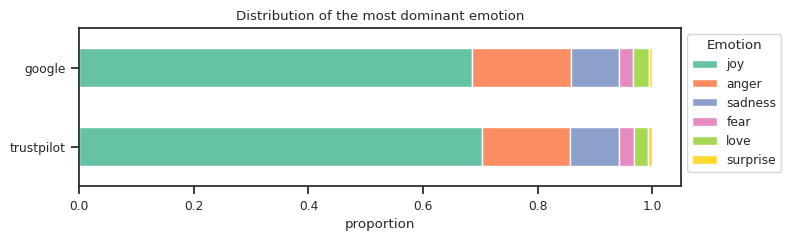

In [233]:
emotions_tp = processed_data_tp["top_emotion"].value_counts(normalize=True)
emotions_g = processed_data_g["top_emotion"].value_counts(normalize=True)

emotions_df = pd.DataFrame({
    "trustpilot": emotions_tp,
    "google": emotions_g
})

emotions_df = emotions_df.sort_values(by="trustpilot", ascending=False)

# Stacked bar
ax = emotions_df.T.plot(
    kind="barh",
    stacked=True,
    figsize=(8, 2.5),
    color=palette_set2
)

plt.title("Distribution of the most dominant emotion")
plt.xlabel("proportion")
plt.legend(title="Emotion", bbox_to_anchor=(1, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Emotion analysis across all reviews shows **joy** as the dominant emotion. However, to better isolate customer pain points, we restrict the analysis to negative reviews only, thereby filtering out satisfied experiences and focusing on sources of dissatisfaction.

### *focus: negative reviews*

**Trustpilot**

In [234]:
processed_data_neg_tp.head(1)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name,data_source
2,"[extremely, busy, fresh, air]","[extremely, busy, no, fresh, air]",extremely busy no fresh air,1,"Extremely busy, no fresh air.",sutton times square,trustpilot


In [235]:
# Get the top emotion for each negative review
processed_data_neg_tp["top_emotion"] = get_top_emotion(processed_data_neg_tp, "review_content", emotion_classifier)

In [236]:
processed_data_neg_tp["top_emotion"].value_counts(normalize=True)

,proportion
top_emotion,
anger,0.45
joy,0.24
sadness,0.23
fear,0.05
love,0.02
surprise,0.01


**Google**

In [237]:
processed_data_neg_g.head(1)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name,data_source
1,"[many, students, two, local, colleges, go, lea...","[too, many, students, from, two, local, colleg...",too many students from two local colleges go h...,1,Too many students from two local colleges go h...,cambridge leisure park,google


In [238]:
# Get the top emotion for each negative review
processed_data_neg_g["top_emotion"] = get_top_emotion(processed_data_neg_g, "review_content", emotion_classifier)

In [239]:
processed_data_neg_g["top_emotion"].value_counts(normalize=True)

,proportion
top_emotion,
anger,0.43
sadness,0.25
joy,0.23
fear,0.06
love,0.02
surprise,0.01


**Combined**

In [240]:
processed_data_neg.head(1)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name,data_source
2,"[extremely, busy, fresh, air]","[extremely, busy, no, fresh, air]",extremely busy no fresh air,1,"Extremely busy, no fresh air.",sutton times square,trustpilot


In [241]:
# Get the top emotion for each negative review - Overall
processed_data_neg["top_emotion"] = get_top_emotion(processed_data_neg, "review_content", emotion_classifier)

In [242]:
processed_data_neg["top_emotion"].value_counts(normalize=True)

,proportion
top_emotion,
anger,0.44
sadness,0.24
joy,0.24
fear,0.06
love,0.02
surprise,0.01


Visualising the distribution of the most dominant emotion across negative reviews:

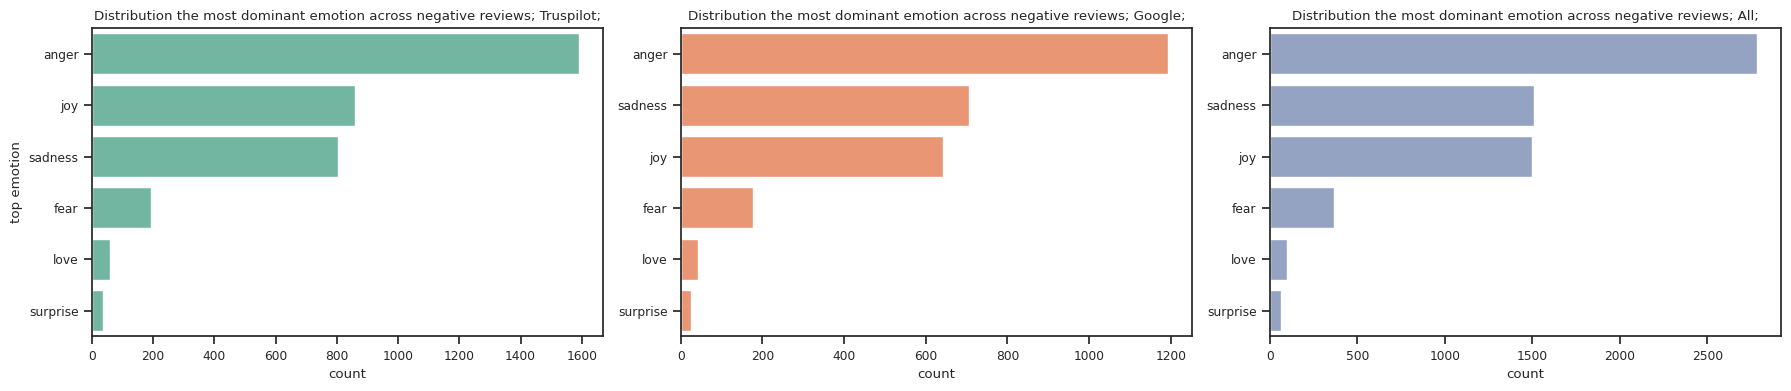

In [243]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes = axes.flatten()

# Plot top emotions
sns.countplot(
    data=processed_data_neg_tp,
    y="top_emotion",
    ax=axes[0],
    color=palette_set2[0],
    order=processed_data_neg_tp["top_emotion"].value_counts().index
)
sns.countplot(
    data=processed_data_neg_g,
    y="top_emotion",
    ax=axes[1],
    color=palette_set2[1],
    order=processed_data_neg_g["top_emotion"].value_counts().index
)
sns.countplot(
    data=processed_data_neg,
    y="top_emotion",
    ax=axes[2],
    color=palette_set2[2],
    order=processed_data_neg["top_emotion"].value_counts().index
)


axes[0].set_title("Distribution the most dominant emotion across negative reviews; Truspilot;")
axes[1].set_title("Distribution the most dominant emotion across negative reviews; Google;")
axes[2].set_title("Distribution the most dominant emotion across negative reviews; All;")

axes[0].set_ylabel("top emotion")
axes[1].set_ylabel(None)
axes[2].set_ylabel(None)

plt.tight_layout()
plt.show()

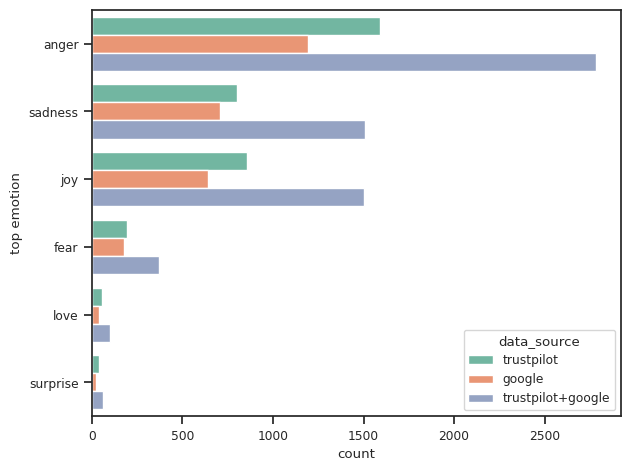

In [244]:
processed_data_neg["data_source"] = "trustpilot+google"

combined_neg_data = pd.concat([
    processed_data_neg_tp,
    processed_data_neg_g,
    processed_data_neg
])

# Plot top emotions
sns.countplot(
    data=combined_neg_data,
    y="top_emotion",
    hue="data_source",
    order=combined_neg_data['top_emotion'].value_counts().index
)

plt.ylabel("top emotion")
plt.tight_layout()
plt.show()

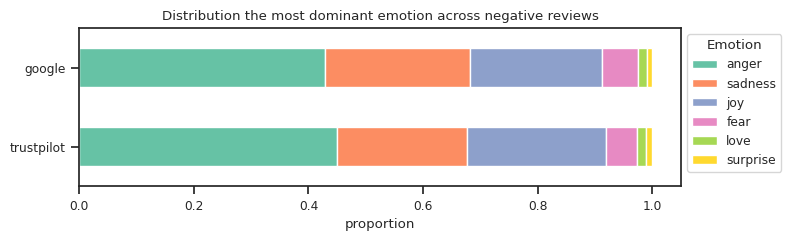

In [245]:
emotions_neg_tp = processed_data_neg_tp["top_emotion"].value_counts(normalize=True)
emotions_neg_g = processed_data_neg_g["top_emotion"].value_counts(normalize=True)

emotions_neg_df = pd.DataFrame({
    "trustpilot": emotions_neg_tp,
    "google": emotions_neg_g
})

emotions_neg_df = emotions_neg_df.sort_values(by="google", ascending=False)

# Stacked bar
ax = emotions_neg_df.T.plot(
    kind="barh",
    stacked=True,
    figsize=(8, 2.5),
    color=palette_set2
)

plt.title("Distribution the most dominant emotion across negative reviews")
plt.xlabel("proportion")
plt.legend(title="Emotion", bbox_to_anchor=(1, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

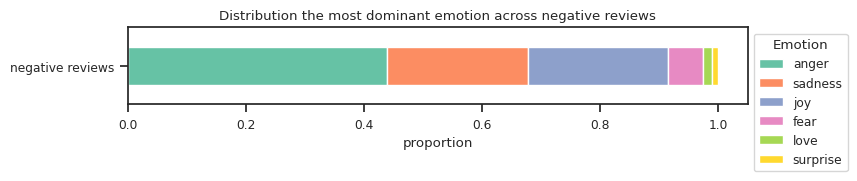

In [246]:
emotions_neg = processed_data_neg["top_emotion"].value_counts(normalize=True)

emotions_neg_df = pd.DataFrame({
    "negative reviews": emotions_neg
})

# Stacked bar
ax = emotions_neg_df.T.plot(
    kind="barh",
    stacked=True,
    figsize=(8, 1)
)

plt.title("Distribution the most dominant emotion across negative reviews")
plt.xlabel("proportion")
plt.legend(title="Emotion", bbox_to_anchor=(1, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 🔹 Insights

Focusing on negative reviews revealed **anger** as the dominant emotion (44% of all negative reviews), followed by **sadness** and **joy** (24% of all negative reviews each).

Negative reviews can still show joy because emotion models detect emotional tone, not overall sentiment. Joy may appear when a reviewer praises a small aspect or uses sarcasm.

To better understand pain points, we will concentrate on reviews expressing **anger** and extract the underlying topics using `BERTopic`.

## BERTopic

### *focus: angry reviews*

Extracting all negative reviews that express anger:

In [247]:
processed_data_anger = processed_data_neg[processed_data_neg["top_emotion"] == "anger"]

In [248]:
# BERTopic needs a list of strings (one string per document (review))
anger_docs = [" ".join(tokens) for tokens in processed_data_anger["filtered_tokens"]]
len(anger_docs)

2783

In [249]:
# Initialise the model
bertopic_model = BERTopic(
    umap_model=umap_model,
    calculate_probabilities=bertopic_config["calculate_probabilities"],
    verbose=bertopic_config["verbose"]
)

In [250]:
# # Fit and transform on the data
# topic, probs = bertopic_model.fit_transform(anger_docs)

In [251]:
# # Define the path
# timestamp = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
# bertopic_model_path = f"{model_dir}/bertopic_model_anger_{timestamp}"
# # Create directory
# os.makedirs(model_dir, exist_ok=True)
# # Save the model
# bertopic_model.save(bertopic_model_path)

In [252]:
# # Configure your git identity
# !git config --global user.email "d.yarparvar@gmail.com"
# !git config --global user.name "Darya Yarparvar"

In [253]:
# # Push
# !git add .
# !git commit -m "Update BERTopic model; angry negative reviews. (location_name issue fixed)"
# !git push

In [254]:
# Load the model
bertopic_model = BERTopic.load(f"{model_dir}/bertopic_model_anger_20251224-200237")

In [255]:
# BERTopic results
bertopic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1101,-1_equipment_people_staff_time,"[equipment, people, staff, time, members, memb...",[today first day let recently started working ...
1,0,203,0_tr_maskiner_center_rlig,"[tr, maskiner, center, rlig, nie, ger, st, per...",[lille reminder folk p nogen sikker p skab st ...
2,1,100,1_rude_staff_manager_customers,"[rude, staff, manager, customers, extremely, d...","[rude staff especially management, manager rud..."
3,2,82,2_class_classes_booked_cancelled,"[class, classes, booked, cancelled, book, inst...",[waste time money instructors giving classes s...
4,3,78,3_pass_day_code_pin,"[pass, day, code, pin, bought, paid, got, emai...","[bought day pass never got sent code, day pass..."


Topic -1 (outliers) has 1101 documents. This is a significant portion of negative reviews (~40%)

The `reduce_outliers` function is applied to assign these outlier documents to the most similar existing topic, ensuring more comprehensive use of the data.


**mapping the outliers to the most similar topic:**

In [256]:
# Calculate the distributions (find the closest topic for outliers)
probabilities = bertopic_model.approximate_distribution(anger_docs)
topics = bertopic_model.topics_

# Use distributions to map outliers to the most similar topic
new_topics = bertopic_model.reduce_outliers(anger_docs, topics, strategy=bertopic_config["outlier_handling"])

# Update the model with these new assignments
bertopic_model.update_topics(anger_docs, topics=new_topics)

100%|██████████| 3/3 [00:00<00:00,  7.03it/s]
2026-01-18 10:15:39,531 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [257]:
# BERTopic results
bertopic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,0,207,0_tr_maskiner_center_rlig,"[tr, maskiner, center, rlig, ger, nie, st, per...",[lille reminder folk p nogen sikker p skab st ...
1,1,123,1_rude_staff_manager_customers,"[rude, staff, manager, customers, unprofession...","[rude staff especially management, manager rud..."
2,2,92,2_class_classes_booked_cancelled,"[class, classes, booked, cancelled, instructor...",[waste time money instructors giving classes s...
3,3,111,3_pass_day_code_pin,"[pass, day, code, pin, bought, paid, get, emai...","[bought day pass never got sent code, day pass..."
4,4,96,4_fee_joining_code_discount,"[fee, joining, code, discount, charged, promo,...","[joining fee others offer joining fee, charged..."


In [258]:
# Top topics along with frequencies
bertopic_model.get_topic_info().sort_values(by="Count", ascending=False).head(n_clusters)

,Topic,Count,Name,Representation,Representative_Docs
0,0,207,0_tr_maskiner_center_rlig,"[tr, maskiner, center, rlig, ger, nie, st, per...",[lille reminder folk p nogen sikker p skab st ...
1,1,123,1_rude_staff_manager_customers,"[rude, staff, manager, customers, unprofession...","[rude staff especially management, manager rud..."
37,37,122,37_changing_equipment_cleaning_machines,"[changing, equipment, cleaning, machines, memb...",[stars might harsh rating matter importance jo...
10,10,116,10_customer_contact_service_email,"[customer, contact, service, email, number, re...",[actual fine customer service basically total ...
5,5,111,5_cancel_membership_refund_cancelled,"[cancel, membership, refund, cancelled, paymen...",[trying cancel membership almost impossible st...
3,3,111,3_pass_day_code_pin,"[pass, day, code, pin, bought, paid, get, emai...","[bought day pass never got sent code, day pass..."
26,26,105,26_equipment_people_place_weights,"[equipment, people, place, weights, machines, ...",[using pure years worst worst worst bench pres...
4,4,96,4_fee_joining_code_discount,"[fee, joining, code, discount, charged, promo,...","[joining fee others offer joining fee, charged..."
2,2,92,2_class_classes_booked_cancelled,"[class, classes, booked, cancelled, instructor...",[waste time money instructors giving classes s...
11,11,75,11_gyms_membership_access_cancel,"[gyms, membership, access, cancel, month, fee,...",[extremely expensive prices cant afford pay pl...


In [259]:
# Words representing the top topics
bertopic_model.get_topic_info().sort_values(by="Count", ascending=False).head(n_clusters)["Representation"].to_list()

[['tr',
  'maskiner',
  'center',
  'rlig',
  'ger',
  'nie',
  'st',
  'personalet',
  'ved',
  'ret'],
 ['rude',
  'staff',
  'manager',
  'customers',
  'unprofessional',
  'attitude',
  'extremely',
  'disrespectful',
  'management',
  'people'],
 ['changing',
  'equipment',
  'cleaning',
  'machines',
  'members',
  'room',
  'rooms',
  'clean',
  'staff',
  'showers'],
 ['customer',
  'contact',
  'service',
  'email',
  'number',
  'response',
  'phone',
  'reply',
  'emails',
  'tried'],
 ['cancel',
  'membership',
  'refund',
  'cancelled',
  'payment',
  'month',
  'charged',
  'email',
  'money',
  'direct'],
 ['pass',
  'day',
  'code',
  'pin',
  'bought',
  'paid',
  'get',
  'email',
  'sent',
  'access'],
 ['equipment',
  'people',
  'place',
  'weights',
  'machines',
  'members',
  'staff',
  'training',
  'one',
  'use'],
 ['fee',
  'joining',
  'code',
  'discount',
  'charged',
  'promo',
  'applied',
  'join',
  'month',
  'paid'],
 ['class',
  'classes',
  'booke

In [260]:
# The most frequent topic
pd.DataFrame(bertopic_model.get_topic(0), columns=["representation", "probability"])

,representation,probability
0,tr,0.04
1,maskiner,0.04
2,center,0.03
3,rlig,0.03
4,ger,0.02
5,nie,0.02
6,st,0.02
7,personalet,0.02
8,ved,0.02
9,ret,0.02


In [261]:
# The second most frequent topic
pd.DataFrame(bertopic_model.get_topic(1), columns=["representation", "probability"])

,representation,probability
0,rude,0.06
1,staff,0.04
2,manager,0.04
3,customers,0.03
4,unprofessional,0.02
5,attitude,0.02
6,extremely,0.02
7,disrespectful,0.02
8,management,0.02
9,people,0.01


In [262]:
# Interactive visualisation of the topics
bertopic_model.visualize_topics()

In [263]:
# Bar chart of the topics including the top 5 words in each topic
bertopic_model.visualize_barchart()

In [264]:
# Heatmap(similarity matrix) of the topics
bertopic_model.visualize_heatmap()

In [265]:
# Hierarchical visualisation of the topics
hierarchical_topics = bertopic_model.hierarchical_topics(anger_docs)
bertopic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 45/45 [00:00<00:00, 300.00it/s]


### 🔹 Insights

The top topics extracted from negative reviews expressing anger:

1. Complaints about equipment, the centre, and staff (7.4%)
    - words: tr, maskiner (machines), center, rlig, ger, nie, st, personalet (staff), ved, ret

2. Unprofessional behaviour of staff or management (4.4%)
    - words: rude, staff, manager, customers, unprofessional, attitude, extremely, disrespectful, management, people

3. Issues with hygiene, cleanliness of changing rooms, showers, machines, and equipment (4.4%)
    - words: changing, equipment, cleaning, machines, members, room, rooms, clean, staff, showers

4. Unsatisfactory customer service, and delayed responses (4.2%)
    - words: customer, contact, service, email, number, response, phone, reply, emails, tried

5. Complaints about cancelling memberships, obtaining refunds, and payment issues (4.0%)
    - words: cancel, membership, refund, cancelled, payment, month, charged, email, money, direct

6. Problems with day passes, access codes, PINs, and payments (4.0%)
    - words: pass, day, code, pin, bought, paid, get, email, sent, access

7. Problems with equipment training and difficulty using machines (3.8%)
    - words: equipment, people, place, weights, machines, members, staff, training, one, use

8. Complaints about joining fees, promotional discounts, and charges (3.4%)
    - words: fee, joining, code, discount, charged, promo, applied, join, month, paid

9. Issues with class scheduling, cancellations, and instructors (3.3%)
    - words: class, classes, booked, cancelled, instructors, book, instructor, one, week, time

10. Issues with membership fee, payment, access, cancellations, and contract (2.7%)
    - words: gyms, membership, access, cancel, month, fee, plus, paid, pay, contract





- In the intertopic distance map, several dense clusters with partial overlap indicate a small number of dominant complaint families expressed through multiple nuanced variations. The top 10 topics are are distributed across 3 of these overlapping regions, and therefore capture the main triggering points for anger.


- In a well-performing BERTopic model, we expect strong internal coherence within each topic and weak similarity between different topics, indicating clean semantic separation. In this heatmap, dark blue squares highlight topics that are nearly identical, suggesting areas where we could merge categories to simplify the results. Light green areas show distinct, unrelated problems. The presence of some medium similarity is not a modelling flaw but a reflection of real-world, multidimensional complaints.

- The dendrogram indicates that if all reviews are forced into just 2 clusters, they collapse into 2 broad themes centred on:
  - membership, code, email, pin, pass
  - equipment, people, staff, one, machines

  
- The real strength of BERTopic lies in uncovering the finer nuances within the customer concerns, and retaining multiple topics provides a more detailed and practically useful understanding of customer issues as long as the topic space is valid, interpretable, and operationally useful.


# Topic Modelling

## LLM

Next, `Phi4` is used for text generation (instead of `Falcon-7B`) to extract the **top three topics** for each **negative** review.

`Phi4`, with 14 billion parameters, is a High-Performance Small Language Model with LLM capabilities.

`Phi4` offers stronger multilingual understanding than `Falcon-7B`, making it better suited for summarising reviews across different languages. However, it may struggle with local slang, idioms, or culturally specific sarcasm due to its more formal and structured training.

In [ ]:
# Check phi4 is ready
!ollama list

NAME           ID              SIZE      MODIFIED       
phi4:latest    ac896e5b8b34    9.1 GB    15 minutes ago    


In [266]:
ollama_config = config["topic_modelling"]["ollama"]

Try the model on an example negative review:

In [ ]:
example_conversation = [
        {
        "role": "system",
        "content": (
            "You extract topics from customer reviews."
            "No explanations. No colons. No sentences. No labels. No code blocks."
            "Output MUST be a numbered list format, with each one on a new line."
        )
      },
      {
        "role": "user",
        "content": (
            "In the following customer review, pick out the main 3 topics. "
            "Return them in a numbered list format, with each one on a new line: "
            "The weights were rusty and the instructor was 20 minutes late."
        )
      },
      {
        "role": "assistant",
        "content": "1. Rusty equipment\n2. Instructor lateness\n3. Poor maintenance"
      },
      {
          "role": "user",
          "content": (
              "In the following customer review, pick out the main 3 topics and "
              "return them in a numbered list format, with each one on a new line: "
              f"{processed_data_neg["review_content"][1]}"
          )
      }
]

In [ ]:
processed_data_neg["review_content"][1]

'Too many students from two local colleges go her leave rubbish in changing rooms and sit there like there in a canteen. Been going here for 5 years will cancel my membership and go to gym group. This gym is disgusting students hanging around machines and messing around like there at school. Too over crowded.( And their ceo supports the genocide of civilians by Israel). Disgusting people!!'

In [ ]:
example_response = get_llm_topics(example_conversation, ollama_config)
example_response

'1. Student behavior  \n2. Overcrowding  \n3. Management ethics'

In [ ]:
# Convert to a list of topics
flattened_topics = [
    topic.strip()
    for topics in [example_response]
    for topic in re.split(r'\d+\.\s*', topics)
    if topic.strip()
]
flattened_topics

['Student behavior', 'Overcrowding', 'Management ethics']

### *focus: negative reviews*

In [267]:
processed_data_neg.head(1)

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name,data_source,top_emotion
2,"[extremely, busy, fresh, air]","[extremely, busy, no, fresh, air]",extremely busy no fresh air,1,"Extremely busy, no fresh air.",sutton times square,trustpilot+google,joy


In [268]:
processed_data_neg.shape[0]

6326

In [269]:
# Filter out reviews longer than 1000 characters
processed_data_neg = processed_data_neg[
    processed_data_neg["review_content"].str.len() < ollama_config["max_review_length"]
]

In [270]:
processed_data_neg.shape[0]

5997

In [271]:
# Use a managable chunk size and determine the total number of data chunks
chunk_size = ollama_config["review_chunk_size"]
n_chunks = math.ceil(processed_data_neg.shape[0]/chunk_size)
n_chunks

60

In [272]:
# Devide the data into chunks with computationally manageble size
chunked_processed_data_neg = [
    processed_data_neg.iloc[i * chunk_size:(i + 1) * chunk_size]
    for i in range(n_chunks)
]

In [273]:
# # Configure your git identity
# !git config --global user.email "d.yarparvar@gmail.com"
# !git config --global user.name "Darya Yarparvar"

In [274]:
# Set the directory to save LLM results
chunk_dir = results_dir + "/chunks"
print(f"\n LLM result chunk directory: {chunk_dir}")
# Create directory
os.makedirs(chunk_dir, exist_ok=True)


 LLM result chunk directory: /content/NLP-and-Topic-Modelling-of-Customer-Reviews/results//chunks


In [275]:
# # Run Phi4 model on each chunk and save the generated results:
#
# for i, data_chunk in enumerate(chunked_processed_data_neg):
#   llm_topics_neg = [get_llm_topics(review, ollama_config) for review in data_chunk["review_content"]]
#
#   # Define the path for each chunk
#   llm_results_path = f"{chunk_dir}/llm_topics_neg_{i}"
#
#   # Flatten the topic list
#   flattened_topics = [
#       topic.strip()                                # clean whitespace
#       for topics in llm_topics_neg                 # loop through each review
#       for topic in re.split(r"\d+\.\s*", topics)   # split each review
#       if topic.strip()
#   ]
#
#   # Convert to array
#   np_flattened_topics = np.array(flattened_topics)
#
#   # Save the results
#   np.save(llm_results_path, np_flattened_topics)
#
#   # Push
#   !git add .
#   !git commit -m "Update LLM topics for chunks of negative reviews; using Ollama Phi4 (new llm parameters)"
#   !git push

In [276]:
# Load the saved results
llm_topics_neg = []

for i in range(n_chunks):
  np_chunk_llm_neg = np.load(f"{chunk_dir}/llm_topics_neg_{i}.npy", allow_pickle=True)
  llm_topics_neg.extend(np_chunk_llm_neg.tolist())

In [277]:
llm_topics_neg

['High crowd levels',
 'Lack of ventilation',
 'Poor air quality',
 "Poor hygiene in men's changing rooms",
 'Ineffective odor control in toilets',
 'Insufficient regular cleaning efforts',
 'Lack of debit card setup option',
 'Additional joining fee',
 'Customer dissatisfaction',
 'Membership downgrade issues',
 'Double charging problem',
 'Poor customer service response',
 'Poor parking facilities',
 'Insufficient equipment availability',
 'Unhelpful staff and improper weight management',
 'Lack of equipment cleaning',
 'Poorly placed cleaning stations',
 'Improper use of equipment without supervision',
 'Double payment',
 'Unresolved issue',
 'Day pass not received',
 'Poor customer experience in the morning',
 'Lack of access code with day pass purchase',
 'Inadequate staff assistance and facility navigation issues',
 'Easy sign-up process',
 'Fair pricing',
 'Instructor absence during class',
 'Safety concerns',
 'Multiple incidents',
 'Location issues',
 'Code delivery',
 'Non-fu

In [278]:
len(llm_topics_neg)

18507

In [279]:
# Extra topics extracted beyond our expectation (3-topic/review)
len(llm_topics_neg) - 5997*3

516

In [280]:
# Number of generated topics per review
18507/5997

3.0860430215107555

### 🔹 Insights

The `Phi4` model produced 516 additional topics beyond what was expected ($5997*3=17991$). This likely reflects hallucination effects.

Although the temperature was set to 0 to enforce deterministic behaviour, some hallucination can still occur. Particularly when reviews are long or complex, or when the prompt does not explicitly cap the number of topics. To reduce this risk, the prompt can be changed from “Pick out the main 3 topics” to “Pick out up to 3 main topics”, allowing the model to return at most three topics per review.

Further inspection showed that the flattening step also introduced splitting errors. For example, a single topic was incorrectly split into fragments:  
'Initial pricing (£'  
'99)'  

Overall, the model produced an average of 3.09 topics per review. This marginal excess (0.09 topics) is considered acceptable and does not materially affect downstream analysis. At this stage, the results are considered satisfactory, and we proceed by applying `BERTopic` for structured topic consolidation and refinement.

## BERTopic

In [ ]:
bertopic_config = config["topic_modelling"]["bertopic"]

### *focus: main topics - negative reviews*

In [ ]:
len(llm_topics_neg)

18507

In [ ]:
# Initialise the model
bertopic_model = BERTopic(
    language=bertopic_config["language"],
    umap_model=umap_model,
    calculate_probabilities=bertopic_config["calculate_probabilities"],
    verbose=bertopic_config["verbose"]
)

In [ ]:
# Fit and transform on the data
topic, probs = bertopic_model.fit_transform(llm_topics_neg)

2026-01-14 17:49:52,215 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/579 [00:00<?, ?it/s]

2026-01-14 17:50:13,166 - BERTopic - Embedding - Completed ✓
2026-01-14 17:50:13,168 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-14 17:50:57,507 - BERTopic - Dimensionality - Completed ✓
2026-01-14 17:50:57,509 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-14 17:54:58,386 - BERTopic - Cluster - Completed ✓
2026-01-14 17:54:58,397 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-14 17:54:58,708 - BERTopic - Representation - Completed ✓


In [ ]:
# BERTopic results
bertopic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3052,-1_attendance_cold_classes_time,"[attendance, cold, classes, time, toilets, or,...","[Poor facility conditions (cold showers), Paym..."
1,0,174,0_trainers_trainer_personal_training,"[trainers, trainer, personal, training, sessio...","[Inadequate personal trainers, Lack of persona..."
2,1,149,1_workout_workouts_exercise_fitness,"[workout, workouts, exercise, fitness, disrupt...","[Quality workout experience, Inadequate workou..."
3,2,141,2_membership_corporate_status_activation,"[membership, corporate, status, activation, me...","[Membership issues, Membership issues, Members..."
4,3,110,3_insufficient_equipment_peak_attachments,"[insufficient, equipment, peak, attachments, e...","[Insufficient equipment, Insufficient equipmen..."


In [ ]:
3052/18507

0.16491057437726267

Topic -1 contains 3052 documents, ~17% of all negative reviews.

At this stage, outlier documents are not reassigned to the nearest topic in order to preserve topic purity. We retain BERTopic's native outlier detection capability, in contrast to LDA where all documents must be assigned to a topic.

The `reduce_topics` function is applied to compress the topic number to 200 without forcing an aggressive reduction, which would dilute the topics undesirably.

In [ ]:
# Set the number of topics to 200 cluster
n_bertopics = bertopic_config["n_topics"] + 1 # when the outliers are not mapped to the most similar topic
n_clusters = bertopic_config["n_clusters"]

# Reduce the number of topics
bertopic_model.reduce_topics(llm_topics_neg, nr_topics=n_bertopics)

2026-01-13 10:49:34,476 - BERTopic - Topic reduction - Reducing number of topics
2026-01-13 10:49:34,536 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-13 10:49:34,743 - BERTopic - Representation - Completed ✓
2026-01-13 10:49:34,746 - BERTopic - Topic reduction - Reduced number of topics from 573 to 201


In [ ]:
# BERTopic results
bertopic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3052,-1_to_for_cold_and,"[to, for, cold, and, time, or, water, classes,...","[Poor facility conditions (cold showers), Impa..."
1,0,934,0_equipment_insufficient_availability_variety,"[equipment, insufficient, availability, variet...","[Insufficient equipment availability, Insuffic..."
2,1,927,1_gym_gyms_comparison_other,"[gym, gyms, comparison, other, etiquette, with...","[Comparison with other gyms, Comparison with o..."
3,2,689,2_service_customer_response_support,"[service, customer, response, support, poor, c...","[Poor customer service, Poor customer service,..."
4,3,524,3_cleanliness_hygiene_standards_poor,"[cleanliness, hygiene, standards, poor, sanita...","[Poor cleanliness and hygiene, Poor cleanlines..."


In [ ]:
# Top topics along with frequencies
bertopic_model.get_topic_info().sort_values(by="Count", ascending=False).head(n_clusters+1)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3052,-1_to_for_cold_and,"[to, for, cold, and, time, or, water, classes,...","[Poor facility conditions (cold showers), Impa..."
1,0,934,0_equipment_insufficient_availability_variety,"[equipment, insufficient, availability, variet...","[Insufficient equipment availability, Insuffic..."
2,1,927,1_gym_gyms_comparison_other,"[gym, gyms, comparison, other, etiquette, with...","[Comparison with other gyms, Comparison with o..."
3,2,689,2_service_customer_response_support,"[service, customer, response, support, poor, c...","[Poor customer service, Poor customer service,..."
4,3,524,3_cleanliness_hygiene_standards_poor,"[cleanliness, hygiene, standards, poor, sanita...","[Poor cleanliness and hygiene, Poor cleanlines..."
5,4,460,4_overcrowding_crowded_overcrowded_peak,"[overcrowding, crowded, overcrowded, peak, env...","[Overcrowding, Overcrowding, Overcrowding]"
6,5,446,5_staff_unfriendly_behavior_rude,"[staff, unfriendly, behavior, rude, unhelpful,...","[Staff behavior, Staff behavior, Staff behavior]"
7,6,418,6_membership_cancellation_cancelling_benefits,"[membership, cancellation, cancelling, benefit...","[Membership cancellation issues, Membership ca..."
8,7,344,7_air_conditioning_ventilation_functional,"[air, conditioning, ventilation, functional, i...","[Poor air conditioning, Poor air conditioning,..."
9,8,336,8_shower_showers_cold_temperature,"[shower, showers, cold, temperature, water, ho...","[Shower issues, Shower issues, Shower issues]"


In [ ]:
# Words representing the top topics
bertopic_model.get_topic_info().sort_values(by="Count", ascending=False).head(n_clusters+1)["Representation"].to_list()

[['to', 'for', 'cold', 'and', 'time', 'or', 'water', 'classes', 'on', 'of'],
 ['equipment',
  'insufficient',
  'availability',
  'variety',
  'limited',
  'condition',
  'maintenance',
  'quality',
  'out',
  'order'],
 ['gym',
  'gyms',
  'comparison',
  'other',
  'etiquette',
  'with',
  'experience',
  'atmosphere',
  'quality',
  'switch'],
 ['service',
  'customer',
  'response',
  'support',
  'poor',
  'communication',
  'experience',
  'quality',
  'problem',
  'time'],
 ['cleanliness',
  'hygiene',
  'standards',
  'poor',
  'sanitation',
  'maintenance',
  'and',
  'organization',
  'facilities',
  'concerns'],
 ['overcrowding',
  'crowded',
  'overcrowded',
  'peak',
  'environment',
  'times',
  'during',
  'and',
  'messiness',
  'space'],
 ['staff',
  'unfriendly',
  'behavior',
  'rude',
  'unhelpful',
  'unprofessional',
  'attitude',
  'employee',
  'positive',
  'turnover'],
 ['membership',
  'cancellation',
  'cancelling',
  'benefits',
  'difficulty',
  'upgrade',

In [ ]:
# The most frequent topic
pd.DataFrame(bertopic_model.get_topic(0), columns=["representation", "probability"])

,representation,probability
0,equipment,0.05
1,insufficient,0.03
2,availability,0.03
3,variety,0.02
4,limited,0.02
5,condition,0.02
6,maintenance,0.02
7,quality,0.02
8,out,0.01
9,order,0.01


In [ ]:
# The second most frequent topic
pd.DataFrame(bertopic_model.get_topic(1), columns=["representation", "probability"])

,representation,probability
0,gym,0.04
1,gyms,0.03
2,comparison,0.02
3,other,0.02
4,etiquette,0.01
5,with,0.01
6,experience,0.01
7,atmosphere,0.01
8,quality,0.01
9,switch,0.01


In [ ]:
# Interactive visualisation of the topics
bertopic_model.visualize_topics()

In [ ]:
# Bar chart of the topics including the top 5 words in each topic
bertopic_model.visualize_barchart()

In [ ]:
# Heatmap(similarity matrix) of the topics
bertopic_model.visualize_heatmap()

In [ ]:
# Hierarchical visualisation of the topics
hierarchical_topics = bertopic_model.hierarchical_topics(llm_topics_neg)
bertopic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 199/199 [00:00<00:00, 304.21it/s]


### 🔹 Insights

Top 10 key topics distilled from all topics associated with negative reviews (excluding Topic -1):

1. Concerns related to equipment availability, limited variety, out-of-order status, and poor maintenance or condition (5.0%)
    - words: equipment, insufficient, availability, variety, limited, condition, maintenance, quality, out, order

2. Negative comparisons of gym atmosphere, overall experience, and member etiquette, indicating potential switching to alternative gyms (5.0%)
    - words: gym, gyms, comparison, other, etiquette, with, experience, atmosphere, quality, switch

3. Poor customer service, and delayed responses (3.7%)
    - words: service, customer, response, support, poor, communication, experience, quality, problem, time

4. Poor hygiene and sanitation, and inadequate organisation, maintenance, and cleanliness of facilities (2.8%)
    - words: cleanliness, hygiene, standards, poor, sanitation, maintenance, and, organization, facilities, concerns

5. Overcrowding during peak times, and the resulting messiness (2.5%)
    - words: overcrowding, crowded, overcrowded, peak, environment, times, during, and, messiness, space

6. Unprofessional behaviour of staff or management and their unhelpful and unfriendly attitude (2.4%)
    - words: staff, unfriendly, behavior, rude, unhelpful, unprofessional, attitude, employee, positive, turnover

7. Difficulty of the membership cancellation process, restrictions, and suspension issues (2.3%)
    - words: membership, cancellation, cancelling, benefits, difficulty, upgrade, restrictions, process, suspension, duration

8. Ineffective air conditioning and ventilation (1.9%)
    - words: air, conditioning, ventilation, functional, ineffective, non, inadequate, circulation, poor, ac

9. Complaints about shower facilities, temperature and hygiene issues (1.8%)
    - words: shower, showers, cold, temperature, water, hot, dirty, in, facilities, conditions

10. Poor equipment maintenance, resulting in equipment and machines being old, damaged, broken, or rusty (1.5%)
    - words: outdated, broken, old, machines, damaged, equipment, missing, parts, rusty, finding






- In the intertopic distance map, several dense clusters with partial overlap indicate a small number of dominant complaint families expressed through multiple nuanced variations. The top 10 topics are distributed across various overlapping regions, and therefore capture a diverse range of pain points.


- In a well-performing BERTopic model, we expect strong internal coherence within each topic and weak similarity between different topics, indicating clean semantic separation. In this heatmap, dark blue squares highlight topics that are nearly identical, suggesting areas where we could merge categories to simplify the results. Light green areas show distinct, unrelated problems. The presence of some medium similarity is not a modelling flaw but a reflection of real-world, multidimensional complaints.

- The dendrogram shows a homogeneous, step-by-step merge, suggesting that sub-topics consolidate into major themes.


  
- The real strength of BERTopic lies in uncovering the finer nuances within the customer concerns, and retaining multiple topics provides a more detailed and practically useful understanding of customer issues as long as the topic space is valid, interpretable, and operationally useful.




## Gensim (LDA)


Here, we apply `LDA` as a traditional topic modelling baseline. `LDA` is computationally lightweight and serves as a methodological validation, allowing us to extract and compare the top 10 topics from negative reviews against more advanced models.

In [ ]:
gensim_config = config["topic_modelling"]["gensim"]

### *focus: negative reviews*

In [ ]:
processed_data_neg["review_stars"].nunique()

2

In [ ]:
processed_data_neg.head()

,filtered_tokens,tokens,review_processed,review_stars,review_content,location_name,data_source,top_emotion
2,"[extremely, busy, fresh, air]","[extremely, busy, no, fresh, air]",extremely busy no fresh air,1,"Extremely busy, no fresh air.",sutton times square,trustpilot+google,joy
19,"[changing, rooms, smell, bad, need, deep, clea...","[the, men, s, changing, rooms, smell, bad, the...",the men s changing rooms smell bad they need a...,2,The men’s changing rooms smell bad. They need ...,leeds city centre south,trustpilot+google,joy
35,"[wanted, set, another, debit, card, direct, de...","[all, i, wanted, to, do, was, set, up, another...",all i wanted to do was set up another debit ca...,1,All I wanted to do was set up another debit ca...,nan,trustpilot+google,joy
36,"[ever, downgrade, membership, core, plus, canc...","[what, ever, you, do, don, t, downgrade, your,...",what ever you do don t downgrade your membersh...,1,What ever you do don’t downgrade your membersh...,nan,trustpilot+google,sadness
38,"[poor, parking, enough, kit, unhelpful, traine...","[poor, parking, not, enough, kit, unhelpful, t...",poor parking not enough kit unhelpful trainers...,2,"Poor parking, not enough kit, unhelpful traine...",nan,trustpilot+google,sadness


In [ ]:
# Create dictionary
dictionary = corpora.Dictionary(processed_data_neg["filtered_tokens"])

In [ ]:
# Convert documents to Bag-of-Words
corpus = [dictionary.doc2bow(tokens) for tokens in processed_data_neg["filtered_tokens"]]

In [ ]:
# Train LDA
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=gensim_config["num_topics"],
    passes=gensim_config["passes"],
    random_state=SEED
)

In [ ]:
lda_model.print_topics()[1]

(1,
 '0.026*"staff" + 0.010*"one" + 0.009*"member" + 0.009*"time" + 0.008*"people" + 0.008*"manager" + 0.008*"would" + 0.007*"members" + 0.007*"like" + 0.007*"rude"')

Visualisation of the top ten topics, displaying the distance maps and the bar chart listing out the most salient terms:

In [ ]:
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

### 🔹 Insights

- The LDA model extracted 10 topics from negative reviews, with "equipment", "staff", "machines", and "membership" dominating the most salient terms across the entire model. Facility-related terms ("changing," "showers," "air," "water," "dirty," "toilets," "hot," "cold") cluster at mid-range saliency, while access terms ("day," "pass," "code," "pin") show moderate presence, validating the core complaint themes identified across word frequency and BERTopic.


- λ = 1 provides the most frequent complaint terms overall and is useful for understanding dominant themes. While lower λ values, such as 0.3 emphasises topic-specific terms and is helpful for identifying unique characteristics of each complaint category.

- λ = 0.6 provides a good balance of frequency and distinctiveness and therefore the optimal interpretable topic differentiation (Sievert and Shirley, 2014). Topics 1, 2, and 4 form the dominant complaint space in the intertopic distance map, collectively representing 55.4% of tokens. Topic 1 is dominated by equipment-related terms, Topic 2 by staff complaints, and Topic 4 by facility conditions. The spatial proximity of these topics in semantic space suggests they represent interconnected dimensions of operational failure.

- Topics 3 and 5 form a separate but closely positioned cluster (22.9% combined), representing similar systemic problems: customers struggle with membership processes and technical access infrastructure.

- Topic 7 mainly contains non-English tokens that LDA failed to semantically integrate, mirroring the multilingual processing limitations observed in BERTopic analysis. It also creates noise through high-frequency, single-letter tokens that likely stem from language-specific characters or encoding issues during preprocessing. Traditional LDA groups different languages if they co-occur, but it cannot understand the semantic link between them without translation or using embeddings.

- Niche topics emerged as distinct clusters: Topic 8 (5%) isolates amenity complaints, representing facility infrastructure issues beyond core gym operations; Topic 9 (3.1%) captures ambiance disruptions; Topic 10 (2.7%) focuses on operational problems. These specialised topics demonstrate LDA's ability to segment complaints into actionable categories despite their smaller token proportions.

# Actionable Insights

Next, we use `Phi4` to convert the list of topics extracted from negative reviews into actionable insights. This step shifts the analysis from describing what happened to defining what should be done, grouping recurring issues into strategic priorities for the relevant organisational teams.


In [ ]:
insight_config = config["insights"]

Try the model on a few example topics:

In [ ]:
len(llm_topics_neg)

18507

In [ ]:
# Retain the unique topics only
llm_topics_neg_set = set(llm_topics_neg)
len(llm_topics_neg_set)

12061

In [ ]:
llm_topics_neg[0:5]

['High crowd levels',
 'Lack of ventilation',
 'Poor air quality',
 "Poor hygiene in men's changing rooms",
 'Ineffective odor control in toilets']

In [ ]:
print(get_llm_insights(llm_topics_neg[0:5], insight_config))

1. Executive Leadership: Capacity Management - Conduct a capacity analysis to identify peak times and consider expanding membership tiers or introducing time slots to manage high crowd levels, potentially increasing revenue through premium memberships.

2. Operations Managers: Facility Layout Optimization - Reassess the gym layout to improve airflow and ventilation systems, ensuring adequate air circulation in crowded areas to enhance member comfort and safety.

3. Customer Experience: Air Quality Monitoring - Implement regular air quality assessments and install air purifiers or upgrade HVAC systems to address poor air quality concerns, improving overall customer satisfaction.

4. Gym Managers: Hygiene Protocols - Develop a stringent cleaning schedule for men's changing rooms with specific focus on high-touch areas, ensuring adherence through staff training and accountability measures.

5. Marketing Team: Communication Strategy - Launch an awareness campaign highlighting the gym’s com

Chunking is necessary because inputting all data at once can overwhelm the model's context window. This can lead to forgeting the instructions or overlook details. By processing the topics in smaller chunks, we ensure the model maintains focus and captures all key insights.

In [ ]:
# Convert list to Series first
llm_topics_neg_series = pd.Series(list(llm_topics_neg_set))

# Use a managable chunk size and determine the total number of topic chunks
chunk_size = insight_config["topic_chunk_size"]
n_chunks = math.ceil(llm_topics_neg_series.shape[0]/chunk_size)
n_chunks

13

In [ ]:
# Divide the topics into chunks with computationally manageble size
chunked_llm_topics_neg = [
    llm_topics_neg_series.iloc[i * chunk_size : (i + 1) * chunk_size]
    for i in range(n_chunks)
]

In [ ]:
# Run Phi4 model on each chunk and append the generated results:
insights_neg = []

for i, topic_chunk in enumerate(chunked_llm_topics_neg):
  # Get actionable insights
  insight_neg = get_llm_insights(topic_chunk, insight_config)
  insights_neg.append(insight_neg)

0
1
2
3
4
5
6
7
8
9
10
11
12


In [ ]:
insights_neg

["The dataset you've shared appears to be a collection of customer feedback or complaints related to gym facilities, specifically focusing on PureGym. Each entry is labeled with an index number and describes various issues or observations made by customers. Here's a breakdown of the types of concerns mentioned:\n\n1. **Facility Issues:**\n   - Poor cleanliness (e.g., dirty bathrooms, locker areas).\n   - Outdated equipment and facilities.\n   - Lack of essential amenities like water machines, lockers, and showers.\n\n2. **Customer Service Problems:**\n   - Unprofessional or rude staff behavior.\n   - Inadequate communication from management.\n   - Difficulty in resolving issues or obtaining refunds.\n\n3. **Operational Concerns:**\n   - Overcrowding and lack of space.\n   - Equipment hogging by certain groups (e.g., teenagers).\n   - Issues with booking systems and class availability.\n\n4. **Technical Problems:**\n   - Malfunctioning equipment (e.g., rowers, payment machines).\n   - C

In [ ]:
len(insights_neg)

13

In [ ]:
insights_neg_clean = []

for insights in insights_neg:
  # Clean the insights by ignoring the "Here is a breakdown..." part in the insight
  insights_clean = re.findall(r'^\d+\..*', insights, re.MULTILINE)
  insights_neg_clean.append("\n".join(insights_clean))

# Combine all insights
all_insights_neg = "\n".join(insights_neg_clean)
len(all_insights_neg)

8417

In [ ]:
all_insights_neg

"1. **Facility Issues:**\n2. **Customer Service Problems:**\n3. **Operational Concerns:**\n4. **Technical Problems:**\n5. **Pricing and Membership Issues:**\n6. **Health and Safety Concerns:**\n7. **General Dissatisfaction:**\n1. **Cleanliness and Maintenance**:\n2. **Equipment Issues**:\n3. **Staff Behavior and Management**:\n4. **Facility Accessibility and Comfort**:\n5. **Booking and Payment Systems**:\n6. **Customer Service and Communication**:\n7. **Specific Location Issues**:\n8. **General Dissatisfaction**:\n1. **Facility Maintenance and Cleanliness**\n2. **Staff and Customer Service**\n3. **Membership and Fees**\n4. **Equipment Availability and Quality**\n5. **Communication and Transparency**\n6. **Environment and Atmosphere**\n7. **Accessibility and Inclusivity**\n8. **App and Technology Issues**\n9. **General Dissatisfaction**\n1. **Facility Conditions**\n2. **Staff and Management**\n3. **Membership and Pricing**\n4. **Overcrowding and Availability**\n5. **Health and Safety C

In [ ]:
# Distil the insights using a slightly different system prompt for this run
distil_config = config["distil"]
final_insights = get_llm_insights(all_insights_neg, distil_config)

In [ ]:
print(final_insights)

1. [Executive Leadership]: Equipment Quality and Maintenance - Conduct an audit of gym equipment to identify quality issues and develop a long-term investment plan for replacements or upgrades.

2. [Operations Managers]: Facility Upkeep - Prioritize maintenance schedules for changing rooms, showers, and other facilities to ensure they are operational and clean at all times.

3. [Customer Experience]: Functionality Frustration - Implement a real-time reporting system for equipment malfunctions to quickly address functionality issues and minimize customer frustration.

4. [Operations Managers]: Water Machine and Hand Dryer Maintenance - Establish routine checks and maintenance protocols for water machines and hand dryers to ensure they are functional and reliable.

5. [Gym Managers]: Changing Room Availability - Assess the current capacity of changing rooms and consider expanding or reorganizing space to meet member needs, especially during peak hours.

6. [Customer Experience]: Staff Be

### 🔹 Insights

The top 10 actionable insights extracted from negative reviews and corresponding recommendations for improvement:

1. [Executive Leadership]: Equipment Quality and Maintenance - Conduct an audit of gym equipment to identify quality issues and develop a long-term investment plan for replacements or upgrades.

2. [Operations Managers]: Facility Upkeep - Prioritize maintenance schedules for changing rooms, showers, and other facilities to ensure they are operational and clean at all times.

3. [Customer Experience]: Functionality Frustration - Implement a real-time reporting system for equipment malfunctions to quickly address functionality issues and minimize customer frustration.

4. [Operations Managers]: Water Machine and Hand Dryer Maintenance - Establish routine checks and maintenance protocols for water machines and hand dryers to ensure they are functional and reliable.

5. [Gym Managers]: Changing Room Availability - Assess the current capacity of changing rooms and consider expanding or reorganizing space to meet member needs, especially during peak hours.

6. [Customer Experience]: Staff Behavior Training - Develop a comprehensive training program focused on customer service excellence and conflict resolution for all staff members to address issues related to rude behavior.

7. [Operations Managers]: Hygiene Standards - Increase the frequency of cleaning schedules, particularly in high-traffic areas like showers and floors, to maintain hygiene standards and member satisfaction.

8. [Marketing Team]: Brand Perception vs. Reality - Align marketing materials with actual gym offerings by ensuring that all advertised features are available and functional, addressing any misleading information on the website.

9. [Gym Managers]: Overcrowding Management - Implement a booking system or staggered entry times to manage peak-hour congestion and improve member experience during busy periods.

10. [Customer Experience]: Customer Service Support - Establish a dedicated customer service team with clear communication channels (phone, email) to promptly address member concerns and requests for assistance.

# References

Sievert, C. and Shirley, K. (2014). ‘LDAvis: A method for visualizing and interpreting topics.’ Proceedings of the Workshop on Interactive Language Learning, Visualization, and Interfaces, pages 63–70. doi:https://doi.org/10.3115/v1/W14-3110